In [ ]:
!pip install xgboost
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install mysql-connector-python
!pip install LSTM
!pip install Dense
!pip install Dropout
!pip install tensorflow
!pip install Sequential

Test de prophet sur 2 mois: 
(Prophet: Décompose les données météo en trois morceaux simples — une tendance générale, des cycles qui se répètent (jour, année) et l'influence des variables externes — puis les additionne pour prédire la suite.)

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# --- 1. CONNEXION ---
bdd = mysql.connector.connect(
    host="localhost", port=8889, user="root", password="root", database="agriculture"
)
query = "SELECT * FROM releve_meteo WHERE station_id = 1"
df_raw = pd.read_sql(query, bdd)
bdd.close()

# --- 2. PRÉPARATION ---
df_raw['ds'] = pd.to_datetime(df_raw['date']) + pd.to_timedelta(df_raw['heure'])
df_raw['y'] = df_raw['temperature'] - 273.15
df_raw = df_raw.sort_values('ds')

# --- 3. SPLIT POUR COMPARER SUR 2 MOIS (BACKTESTING) ---
# On s'arrête à fin Octobre 2025 pour l'entraînement
date_fin_train = pd.Timestamp('2025-10-31 23:59:59')
train = df_raw[df_raw['ds'] <= date_fin_train]
# On garde Nov/Déc 2025 pour comparer
test_reel = df_raw[df_raw['ds'] > date_fin_train]

m = Prophet(
    yearly_seasonality=10, # On force une saisonnalité annuelle stable
    daily_seasonality=True,
    changepoint_prior_scale=0.01, # On le rend MOINS nerveux pour éviter les dérives
    seasonality_mode='additive'
)
m.fit(train)

# --- 5. PRÉDICTION SUR LA PÉRIODE DE TEST (2 MOIS CONNUS) ---
# On demande au modèle de prédire la période qu'on a déjà
future = test_reel[['ds']]
forecast = m.predict(future)

# --- 6. CALCUL ET GRAPHIQUE ---
res = pd.merge(test_reel[['ds', 'y']], forecast[['ds', 'yhat']], on='ds')
rmse = np.sqrt(mean_squared_error(res['y'], res['yhat']))

plt.figure(figsize=(15, 7))
plt.plot(res['ds'], res['y'], label='Réel (Nov-Déc 2025)', color='black', alpha=0.6)
plt.plot(res['ds'], res['yhat'], label='Prédit par le modèle', color='red', linestyle='--')
plt.title(f"BACKTESTING : Prédiction de fin 2025 (RMSE: {rmse:.2f}°C)")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Sur ces 2 mois, l'erreur moyenne est de {rmse:.2f}°C")

test de prophet sur une semaine

In [ ]:
import pandas as pd
import numpy as np
import glob
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# --- 1. CHARGEMENT ET NETTOYAGE ---
files = sorted(glob.glob("synop_*.csv"))
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True).dt.tz_localize(None)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce').ffill()
df['pres'] = pd.to_numeric(df['pres'], errors='coerce').ffill() / 100

# --- 2. CONFIGURATION ---
cutoff = pd.Timestamp("2026-01-07 21:00:00")
train = df[df['ds'] <= cutoff].copy()

model = Prophet(
    changepoint_prior_scale=15, 
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.add_seasonality(name='yearly', period=365.25, fourier_order=12)
model.add_seasonality(name='daily', period=1, fourier_order=8)
model.add_regressor('u', prior_scale=10)
model.add_regressor('pres', prior_scale=10)

model.fit(train)

# --- 3. PRÉPARATION DU FUTUR ---
future = model.make_future_dataframe(periods=56, freq='3h') 
avg_u = train['u'].tail(24).mean()
avg_pres = train['pres'].tail(24).mean()

future = future.merge(df[['ds', 'u', 'pres']], on='ds', how='left')
future.loc[future['ds'] > cutoff, 'u'] = avg_u
future.loc[future['ds'] > cutoff, 'pres'] = avg_pres

# --- 4. PRÉDICTION ---
forecast = model.predict(future)

# --- 5. EXPORTATION DU CSV (L'OUBLI RÉPARÉ) ---
# On ne garde que les lignes après le cutoff pour le fichier final
forecast_semaine_2 = forecast[forecast['ds'] > cutoff][['ds', 'yhat']]
forecast_semaine_2.to_csv("prophet_semaine_2.csv", index=False)
print("✅ Fichier 'prophet_semaine_2.csv' enregistré avec succès.")


comparaison prédiction prophet avec réel

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. CHARGEMENT DES DONNÉES
try:
    # On charge la prédiction Prophet
    df_pred = pd.read_csv("prophet_semaine_2.csv")
    # On charge la réalité (ton fichier source)
    df_real = pd.read_csv("synop_2026.csv", sep=";")
except FileNotFoundError:
    print("Erreur : Assure-toi que 'prophet_semaine_2.csv' et 'synop_2026.csv' existent.")

# 2. PRÉPARATION ET ALIGNEMENT
df_pred['ds'] = pd.to_datetime(df_pred['ds'])
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True).dt.tz_localize(None)

# Conversion Celsius et filtre Montpellier
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

# Fusion pour ne comparer que les dates communes (Semaine 2)
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

# 3. CALCUL DES MÉTRIQUES ET AFFICHAGE
if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['yhat'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['yhat']))

    plt.figure(figsize=(16, 7))
    
    # Courbes
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel (Janvier 2026)', color='#1f77b4', lw=2)
    plt.plot(df_compare['ds'], df_compare['yhat'], 's--', label='Prophet + Regressors', color='#e31a1c', alpha=0.8)
    
    # Remplissage de l'erreur (facultatif mais visuel)
    plt.fill_between(df_compare['ds'], df_compare['y_real'], df_compare['yhat'], color='gray', alpha=0.2, label='Écart')

    # Style
    plt.title(f"Prophet : Comparaison Semaine 2 | MAE : {mae:.2f}°C | RMSE : {rmse:.2f}°C", fontsize=14)
    plt.ylabel("Température (°C)")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

    print(f"✅ Comparaison terminée.")
    print(f"Erreur Moyenne (MAE) : {mae:.2f}°C")
else:
    print("❌ Aucune donnée commune trouvée entre la prédiction et le fichier réel.")

GriddSearch pour prophet (voir quels sont les meilleurs paramètres)

In [ ]:
import pandas as pd
import numpy as np
import glob
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error

# --- 1. CHARGEMENT ET NETTOYAGE ---
files = sorted(glob.glob("synop_*.csv"))
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True).dt.tz_localize(None)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce').ffill()
df['pres'] = pd.to_numeric(df['pres'], errors='coerce').ffill() / 100

# --- 2. SPLIT AUTOMATIQUE (Dernière semaine en test) ---
# Au lieu de dates fixes, on prend les 56 derniers points (7 jours) pour le test
n_test = 56 
train = df.iloc[:-n_test].copy()
test = df.iloc[-n_test:].copy()

print(f"📈 Entraînement jusqu'au : {train['ds'].max()}")
print(f"📉 Test du {test['ds'].min()} au {test['ds'].max()}")

# --- 3. DÉFINITION DE LA GRILLE ---
param_grid = {  
    'changepoint_prior_scale': [0.05, 0.1, 0.3],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

grid = ParameterGrid(param_grid)
results = []

# --- 4. BOUCLE DE RECHERCHE ---
for p in grid:
    # On force un fourier_order élevé (15) pour bien capter les variations
    m = Prophet(**p, yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
    m.add_seasonality(name='daily', period=1, fourier_order=15) 
    m.add_regressor('u')
    m.add_regressor('pres')
    
    m.fit(train)
    
    # On prédit uniquement sur les dates du test
    future = test[['ds', 'u', 'pres']].copy()
    forecast = m.predict(future)
    
    mae = mean_absolute_error(test['y'], forecast['yhat'])
    results.append({'params': p, 'mae': mae})
    print(f"Config: {p['seasonality_mode'][0]} | CPS: {p['changepoint_prior_scale']} | SPS: {p['seasonality_prior_scale']} --> MAE: {mae:.2f}°C")

# --- 5. RÉSULTAT FINAL ---
best_params = min(results, key=lambda x: x['mae'])
print("\n🏆 MEILLEURS PARAMÈTRES :")
print(best_params)

test des paramètres sortant de grid search en essayant de prédire une journée

In [ ]:
# --- 1. GÉNÉRATION DU FUTUR (8 JANVIER 2026) ---
# On demande 8 points de 3h pour couvrir 24h après le dernier point connu
future_dates = m.make_future_dataframe(periods=8, freq='3h')
future_only = future_dates[future_dates['ds'] > train['ds'].max()].copy()

# On utilise les dernières valeurs de météo connues (Scénario de base)
future_only['u'] = train['u'].iloc[-1]
future_only['pres'] = train['pres'].iloc[-1]

# --- 2. PRÉDICTION ---
forecast = m.predict(future_only)

# --- 3. EXPORT CSV ---
# On ne garde que les colonnes essentielles pour ta comparaison
export_df = forecast[['ds', 'yhat']].copy()
export_df.columns = ['ds', 'y_pred'] # On renomme pour plus de clarté
export_df.to_csv("prophet_24h_test.csv", index=False)

print("✅ Fichier 'prophet_24h_test.csv' généré avec succès.")
print(f"Période couverte : du {export_df['ds'].min()} au {export_df['ds'].max()}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import glob

# --- 1. CHARGEMENT DE LA PRÉDICTION ---
try:
    df_pred = pd.read_csv("prophet_24h_test.csv")
    df_pred['ds'] = pd.to_datetime(df_pred['ds'])
except FileNotFoundError:
    print("❌ Erreur : Le fichier 'prophet_24h_test.csv' n'existe pas.")

# --- 2. CHARGEMENT ET PRÉPARATION DU RÉEL ---
files = sorted(glob.glob("synop_*.csv"))
df_list = []
for f in files:
    temp = pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'name'])
    df_list.append(temp)

df_all = pd.concat(df_list)
df_real = df_all[df_all['name'] == "MONTPELLIER-AEROPORT"].copy()
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True).dt.tz_localize(None)
df_real['y_real'] = df_real['t'] - 273.15

# --- 3. FUSION ET ALIGNEMENT ---
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

# --- 4. CALCUL DES MÉTRIQUES (MAE + RMSE) ---
if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    mse = mean_squared_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mse) # Calcul du RMSE
    bias = (df_compare['y_pred'] - df_compare['y_real']).mean()

    # --- 5. GRAPHIQUE ---
    plt.figure(figsize=(12, 6))
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel (Mesuré)', color='#2c3e50', markersize=8)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='Prophet (Prédit)', color='#e74c3c', markersize=8)
    
    plt.fill_between(df_compare['ds'], df_compare['y_real'], df_compare['y_pred'], color='gray', alpha=0.1)

    # Ajout du RMSE dans le titre
    plt.title(f"Validation Prophet : 8 Janvier 2026\nMAE : {mae:.2f}°C | RMSE : {rmse:.2f}°C | Biais : {bias:+.2f}°C", fontsize=14)
    plt.ylabel("Température (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print(f"📊 RAPPORT DE PERFORMANCE DÉTAILLÉ")
    print(f"----------------------------------")
    print(f"Erreur Moyenne (MAE)  : {mae:.2f} °C")
    print(f"Erreur Quadratique (RMSE) : {rmse:.2f} °C")
    print(f"Biais Moyen           : {bias:+.2f} °C")
    print(f"----------------------------------")
    
else:
    print("❌ Aucune donnée réelle trouvée pour les dates prédites.")

XGBoost = Forêt d'arbres de décision qui apprennent en série : chaque nouvel arbre est construit spécifiquement pour corriger les erreurs de prédiction commises par l'ensemble des arbres précédents, jusqu'à ce que le résultat final soit le plus précis possible.

Test de xgboost en récursif (en réinjectant chaque prédiction comme donnée d'entrée pour calculer le point suivant) sur 2 mois

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# --- 1. CONNEXION ET CHARGEMENT ---
bdd = mysql.connector.connect(
    host="localhost", port=8889, user="root", password="root", database="agriculture"
)
# On récupère tout l'historique de la station Abbeville
df_raw = pd.read_sql("SELECT * FROM releve_meteo WHERE station_id = 1", bdd)
bdd.close()

# --- 2. PRÉPARATION ---
df_raw['ds'] = pd.to_datetime(df_raw['date']) + pd.to_timedelta(df_raw['heure'])
df_raw['y'] = df_raw['temperature'] - 273.15
df_raw = df_raw.sort_values('ds')

# --- 3. DÉFINITION DES TRAINS / TEST ---
# Entraînement : 2022 -> 31 Octobre 2025
train_data = df_raw[df_raw['ds'] < '2025-11-01'].copy()
# Test : Novembre + Décembre 2025 (période à "deviner")
test_reel = df_raw[df_raw['ds'] >= '2025-11-01'].copy()

# Fonction pour extraire les colonnes temporelles
def get_features(df):
    df['hour'] = df['ds'].dt.hour
    df['dayofyear'] = df['ds'].dt.dayofyear
    df['month'] = df['ds'].dt.month
    return df

# Préparation du train avec les Lags réels
train_data = get_features(train_data)
train_data['lag_3h'] = train_data['y'].shift(1)
train_data['lag_6h'] = train_data['y'].shift(2)
train_data['lag_24h'] = train_data['y'].shift(8)
train_data = train_data.dropna()

features = ['hour', 'dayofyear', 'month', 'lag_3h', 'lag_6h', 'lag_24h']
X_train = train_data[features]
y_train = train_data['y']

# --- 4. ENTRAÎNEMENT XGBOOST ---
model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)

# --- 5. PRÉDICTION RÉCURSIVE (Le modèle s'auto-alimente) ---
# On commence avec les dernières valeurs connues du train
last_values = list(train_data['y'].tail(8).values) # On garde les 8 derniers points (24h)
preds_list = []

print("Lancement de la prédiction récursive sur 2 mois...")

for i in range(len(test_reel)):
    row_ds = test_reel.iloc[i]['ds']
    
    # Création de la ligne de caractéristiques avec les PRÉDICTIONS précédentes
    current_features = pd.DataFrame([{
        'hour': row_ds.hour,
        'dayofyear': row_ds.dayofyear,
        'month': row_ds.month,
        'lag_3h': last_values[-1],
        'lag_6h': last_values[-2],
        'lag_24h': last_values[-8]
    }])
    
    # Prédiction du point suivant
    p = model.predict(current_features[features])[0]
    preds_list.append(p)
    
    # Mise à jour des "dernières valeurs" avec la prédiction qu'on vient de faire
    last_values.append(p)
    last_values.pop(0) # On garde toujours une fenêtre de 8 points

# --- 6. RÉSULTATS ET COMPARAISON ---
test_reel['preds'] = preds_list
rmse = np.sqrt(mean_squared_error(test_reel['y'], test_reel['preds']))

plt.figure(figsize=(15, 7))
plt.plot(test_reel['ds'], test_reel['y'], label='Réel (Noir)', color='black', alpha=0.4, linewidth=1)
plt.plot(test_reel['ds'], test_reel['preds'], label='XGBoost Récursif (Bleu)', color='blue', linewidth=1.5)
plt.title(f"BACKTESTING ULTIME : Novembre-Décembre 2025\nRMSE : {rmse:.2f}°C")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Analyse terminée. RMSE : {rmse:.2f}")

In [ ]:
Test xgboost sur 1 jour avec lags (en se basant sur la mémoire immédiate des relevés précédents)

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- 1. CONNEXION ET PRÉPARATION ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
df = pd.read_sql("SELECT * FROM releve_meteo WHERE station_id = 1", bdd)
bdd.close()

df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['heure'])
df['y'] = df['temperature'] - 273.15
df = df.sort_values('ds')

# --- 2. FEATURES AVEC LAGS ---
df['hour'] = df['ds'].dt.hour
df['lag_3h'] = df['y'].shift(1)
df['lag_6h'] = df['y'].shift(2)
df['lag_24h'] = df['y'].shift(8)
df = df.dropna()

# --- 3. SPLIT (On garde les dernières 24h pour le test) ---
# On s'arrête 24h avant la fin pour l'entraînement
split_date = df['ds'].max() - pd.Timedelta(hours=24)
train = df[df['ds'] <= split_date]
test_24h = df[df['ds'] > split_date]

features = ['hour', 'lag_3h', 'lag_6h', 'lag_24h']
X_train, y_train = train[features], train['y']
X_test, y_test = test_24h[features], test_24h['y']

# --- 4. ENTRAÎNEMENT XGBOOST ---
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# --- 5. PRÉDICTION ---
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))

# --- 6. GRAPHIQUE ZOOMÉ SUR 24H ---
plt.figure(figsize=(10, 6))
plt.plot(test_24h['ds'], y_test, label='Réel (Observations)', color='black', marker='o')
plt.plot(test_24h['ds'], preds, label='Prédit (XGBoost)', color='red', linestyle='--', marker='x')

plt.title(f"Prédiction à 24h - Station ABBEVILLE (RMSE: {rmse:.2f}°C)")
plt.xlabel("Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Erreur moyenne sur 24h : {rmse:.2f}°C")

Test XgBoost non récursif sur 1 semaine ( mais du coup ne marchera pas pour nous par ce qu'il utilise les données réelles 3h avant la prédiction)

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- 1. CHARGEMENT ET PRÉPARATION (Même logique que ton LSTM) ---
files = sorted(glob.glob("synop_*.csv"))
if not files:
    print("❌ Aucun fichier synop_*.csv trouvé !")
else:
    # Lecture avec les colonnes spécifiques
    df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', 
                                   usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
    
    # Filtrage Montpellier
    df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('validity_time').copy()
    df['ds'] = pd.to_datetime(df['validity_time'], utc=True).dt.tz_localize(None)
    
    # Conversions
    df['y'] = pd.to_numeric(df['t'], errors='coerce') - 273.15
    df['u'] = pd.to_numeric(df['u'], errors='coerce')
    df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100
    
    # Nettoyage et Interpolation (pour boucher les trous de 3h)
    df = df.set_index('ds').sort_index()
    df = df[['y', 'u', 'pres']].interpolate(method='linear').bfill().ffill()
    df = df.resample('3h').interpolate() # On s'assure d'avoir un point toutes les 3h
    df = df.reset_index()

    # --- 2. FEATURES AVANCÉES ---
    df['hour_sin'] = np.sin(2 * np.pi * df.ds.dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.ds.dt.hour / 24)
    df['lag_3h'] = df['y'].shift(1)
    df['lag_6h'] = df['y'].shift(2)
    df['lag_24h'] = df['y'].shift(8)
    
    df = df.dropna()

    # --- 3. SPLIT CIBLÉ : 1er au 8 JANVIER 2026 ---
    debut_test = pd.Timestamp('2026-01-01 00:00:00')
    fin_test = pd.Timestamp('2026-01-08 23:59:59')

    train = df[df['ds'] < debut_test]
    test_janvier = df[(df['ds'] >= debut_test) & (df['ds'] <= fin_test)]

    if test_janvier.empty:
        print(f"❌ Toujours pas de données en Janvier 2026 !")
        print(f"Dernière date trouvée dans les fichiers : {df['ds'].max()}")
    else:
        features = ['u', 'pres', 'hour_sin', 'hour_cos', 'lag_3h', 'lag_6h', 'lag_24h']
        X_train, y_train = train[features], train['y']
        X_test, y_test = test_janvier[features], test_janvier['y']

        # --- 4. MODÈLE XGBOOST ROBUSTE ---
        model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=4)
        model.fit(X_train, y_train)

        # --- 5. PRÉDICTION ET SCORE ---
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        # --- 6. GRAPHIQUE ---
        plt.figure(figsize=(15, 6))
        plt.plot(test_janvier['ds'], y_test, 'o-', label='Réel (Janvier 2026)', color='black', alpha=0.6)
        plt.plot(test_janvier['ds'], preds, 'r--', label='XGBoost (One-Step)', linewidth=2)
        plt.axhline(0, color='blue', linestyle=':', alpha=0.5)
        
        plt.title(f"XGBoost - Semaine 1 Janv 2026\nRMSE: {rmse:.2f}°C", fontsize=14)
        plt.ylabel("Température (°C)")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()

        print(f"📊 Résultat : {len(test_janvier)} points analysés. RMSE de {rmse:.2f}°C")

XGBoost récursif pour 1 semaine

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- 1. CONNEXION ET PRÉPARATION ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
# On récupère TOUT l'historique jusqu'à fin 2025
df = pd.read_sql("SELECT * FROM releve_meteo WHERE station_id = 1", bdd)
bdd.close()

df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['heure'])
df['y'] = df['temperature'] - 273.15
df = df.sort_values('ds')

# Features d'entraînement
df['hour'] = df['ds'].dt.hour
df['lag_3h'] = df['y'].shift(1)
df['lag_6h'] = df['y'].shift(2)
df['lag_24h'] = df['y'].shift(8)
df_train = df.dropna()

features = ['hour', 'lag_3h', 'lag_6h', 'lag_24h']

# --- 2. ENTRAÎNEMENT (Modèle Robuste) ---
model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=4)
model.fit(df_train[features], df_train['y'])

# --- 3. SIMULATION RÉCURSIVE (Janvier 2026) ---
# On commence au dernier point connu (31 Décembre 2025 à 21h)
history = list(df_train['y'].tail(8).values) # On garde les 24 dernières heures pour les lags
last_date = df_train['ds'].max()

preds = []
# Génération de 56 points (7 jours x 8 relevés/jour)
future_range = pd.date_range(start=last_date + pd.Timedelta(hours=3), periods=56, freq='3h')

for date in future_range:
    # On construit le vecteur de features avec les prédictions précédentes
    h = date.hour
    l3 = history[-1] # T-3h
    l6 = history[-2] # T-6h
    l24 = history[-8] # T-24h
    
    X = pd.DataFrame([[h, l3, l6, l24]], columns=features)
    y_pred = model.predict(X)[0]
    
    preds.append({'ds': date, 'y_pred': y_pred})
    history.append(y_pred) # On injecte la prédiction dans l'historique pour le point suivant

df_forecast = pd.DataFrame(preds)

# --- 4. COMPARAISON AVEC LE RÉEL 2026 ---
# On charge ton CSV que tu as mis de côté
df_real_2026 = pd.read_csv("synop_2026.csv", sep=None, engine='python')
df_real_2026['ds'] = pd.to_datetime(df_real_2026['validity_time'], utc=True).dt.tz_localize(None)
df_real_2026['y_real'] = df_real_2026['t'] - 273.15

# Merge pour comparer
comp = pd.merge(df_forecast, df_real_2026[df_real_2026['name'] == 'MONTPELLIER-AEROPORT'], on='ds')
rmse = np.sqrt(mean_squared_error(comp['y_real'], comp['y_pred']))

# --- 5. GRAPHIQUE ---
plt.figure(figsize=(15, 7))
plt.plot(comp['ds'], comp['y_real'], label='Réel 2026', color='black', lw=2)
plt.plot(comp['ds'], comp['y_pred'], label='XGBoost Récursif (7j)', color='blue', ls='--')
plt.axhline(0, color='red', alpha=0.3)
plt.title(f"Test 7 jours Janvier 2026 - RMSE: {rmse:.2f}°C")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

xgboost en incluant des variables explicatives tel que l'humidité (mais non utilisable pour le projet comme on aura pas non plus ses variables)

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
query = """
    SELECT date, heure, temperature, point_de_rose, humidite, 
           temperature_min_sol_12h, precipitations_dernieres_24h 
    FROM releve_meteo WHERE station_id = 1
"""
df = pd.read_sql(query, bdd)
bdd.close()

# Conversion et préparation de la cible (Celsius)
df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['heure'])
df['y'] = pd.to_numeric(df['temperature']) - 273.15
df = df.sort_values('ds')

# --- 2. FEATURE ENGINEERING CIBLÉ ---
# Liste des colonnes météo utiles pour les lags
meteo_cols = ['y', 'point_de_rose', 'humidite', 'temperature_min_sol_12h', 'precipitations_dernieres_24h']

for col in meteo_cols:
    # On convertit en float pour éviter les problèmes de type 'decimal'
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Création des lags
    df[f'{col}_lag3h'] = df[col].shift(1)
    df[f'{col}_lag6h'] = df[col].shift(2)
    df[f'{col}_lag24h'] = df[col].shift(8)

# Variables temporelles
df['hour'] = df['ds'].dt.hour
df['day_of_year'] = df['ds'].dt.dayofyear

df = df.dropna()

# --- 3. SPLIT (Validation 7 jours) ---
date_test = df['ds'].max() - pd.Timedelta(days=7)
train = df[df['ds'] <= date_test]
test = df[df['ds'] > date_test]

# On définit les features (uniquement les lags et le temps)
features = [c for c in df.columns if '_lag' in c] + ['hour', 'day_of_year']

X_train, y_train = train[features], train['y']
X_test, y_test = test[features], test['y']

# --- 4. MODÈLE XGBOOST ---
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)
model.fit(X_train, y_train)

# --- 5. PRÉDICTIONS ET RÉSULTATS ---
preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))

plt.figure(figsize=(15, 6))
plt.plot(test['ds'], y_test, label='Réel (Celsius)', color='black', alpha=0.5, marker='.')
plt.plot(test['ds'], preds, label='XGBoost Expert', color='orange', linestyle='--')
plt.title(f"XGBoost avec Variables Météo - RMSE: {rmse:.2f}°C")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# --- 6. ANALYSE D'IMPORTANCE ---
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Top des variables prédictives ---")
print(importance.head(10))

test de XGBoost entrainé sur toutes les villes simultanément

Utilise le point de rosée et le temp_trend (vitesse de variation) pour prédire précisément la température de chaque station_id.
avec a la fin un test sur un station

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
df_raw = pd.read_sql("SELECT * FROM releve_meteo", bdd)
bdd.close()

# On s'assure que les colonnes sont bien là
print("Colonnes détectées :", df_raw.columns.tolist())

df = df_raw.copy()
df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['heure'])
df['y'] = pd.to_numeric(df['temperature']) - 273.15
df = df.sort_values(['station_id', 'ds'])

# --- 2. FEATURE ENGINEERING (Simple et robuste) ---
df_list = []
# On boucle sur chaque station manuellement pour créer les lags sans mélanger les villes
for sid in df['station_id'].unique():
    sub = df[df['station_id'] == sid].copy()
    
    # Lags
    sub['y_lag3h'] = sub['y'].shift(1)
    sub['y_lag24h'] = sub['y'].shift(8)
    sub['pr_lag3h'] = pd.to_numeric(sub['point_de_rose'], errors='coerce').shift(1) - 273.15
    
    # Features temporelles
    sub['hour'] = sub['ds'].dt.hour
    sub['temp_trend'] = sub['y_lag3h'] - sub['y_lag24h']
    
    df_list.append(sub)

df_final = pd.concat(df_list).dropna()

# --- 3. SPLIT MANUEL (Anti-KeyError) ---
features = ['station_id', 'hour', 'y_lag3h', 'y_lag24h', 'pr_lag3h', 'temp_trend']

train_list = []
test_list = []

for sid in df_final['station_id'].unique():
    station_data = df_final[df_final['station_id'] == sid]
    # On prend les 8 dernières lignes (24h) pour le test, le reste pour le train
    train_list.append(station_data.iloc[:-8])
    test_list.append(station_data.tail(8))

df_train = pd.concat(train_list)
df_test = pd.concat(test_list)

# --- 4. ENTRAÎNEMENT GLOBAL ---
model = XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=7)
model.fit(df_train[features], df_train['y'])

# --- 5. TEST SUR LA STATION 3 ---
ID_CIBLE = 3
test_sub = df_test[df_test['station_id'] == ID_CIBLE]

if not test_sub.empty:
    preds = model.predict(test_sub[features])
    rmse = np.sqrt(mean_squared_error(test_sub['y'], preds))
    
    print(f"\n✅ RÉSULTAT GLOBAL - STATION {ID_CIBLE}")
    print(f"📊 RMSE : {rmse:.2f}°C")
    
    res = pd.DataFrame({
        'Heure': test_sub['ds'].dt.strftime('%H:%M'), 
        'Réel': test_sub['y'].values, 
        'Prédit': [round(p, 2) for p in preds]
    })
    print("\n", res.to_string(index=False))
else:
    print(f"Aucune donnée pour la station {ID_CIBLE}")

test avec deux modèles en simultané,  un premier modèle apprend la physique météo globale, tandis qu'un second corrige les erreurs spécifiquement pour chaque station_id. (xgboost) (non utilisable pour le projet)

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- 1. CHARGEMENT ET PRÉPARATION ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
df_raw = pd.read_sql("SELECT * FROM releve_meteo", bdd)
bdd.close()

df = df_raw.copy()
df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['heure'])
df['y'] = pd.to_numeric(df['temperature']) - 273.15
df = df.sort_values(['station_id', 'ds'])

# Feature Engineering
df_list = []
for sid in df['station_id'].unique():
    sub = df[df['station_id'] == sid].copy()
    sub['y_lag3h'] = sub['y'].shift(1)
    sub['y_lag24h'] = sub['y'].shift(8)
    sub['hour'] = sub['ds'].dt.hour
    # La variable "Climat" : température moyenne de la station sur 3 jours
    sub['climat_local'] = sub['y'].rolling(window=24).mean().shift(1)
    df_list.append(sub)

df_final = pd.concat(df_list).dropna()

# --- 2. APPRENTISSAGE GLOBAL (La tendance France) ---
# Ce modèle apprend la physique générale de la météo
features_global = ['hour', 'y_lag3h', 'y_lag24h']
model_global = XGBRegressor(n_estimators=500, learning_rate=0.05)
model_global.fit(df_final[features_global], df_final['y'])

# On calcule la prédiction globale pour tout le monde
df_final['pred_global'] = model_global.predict(df_final[features_global])

# --- 3. CALCUL DE L'ERREUR LOCALE (Le Résidu) ---
# L'écart entre la "France" et la "Station"
df_final['erreur_nationale'] = df_final['y'] - df_final['pred_global']

# --- 4. MODÈLE DE CORRECTION SPÉCIFIQUE (Le Meta-Modèle) ---
# Ce modèle apprend à corriger l'erreur nationale en fonction de la station
features_meta = ['station_id', 'hour', 'climat_local', 'pred_global']
model_meta = XGBRegressor(n_estimators=500, learning_rate=0.03)
model_meta.fit(df_final[features_meta], df_final['erreur_nationale'])

# --- 5. PRÉDICTION FINALE ---
# On combine : Tendance Nationale + Correction Locale
df_final['correction_locale'] = model_meta.predict(df_final[features_meta])
df_final['y_final'] = df_final['pred_global'] + df_final['correction_locale']

# --- 6. VÉRIFICATION DES SCORES ---
for sid in df_final['station_id'].unique():
    sub_test = df_final[df_final['station_id'] == sid].tail(8)
    rmse = np.sqrt(mean_squared_error(sub_test['y'], sub_test['y_final']))
    print(f"✅ Station {sid} | RMSE Final : {rmse:.2f}°C")

après des rmse très variables a la suite du teste precedent on test Xgboost en apportant des cluster sur les stations. Ce qui parait logique puisque la france est grande et a des variabilité très différentes selon la situation géographique

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- 1. CHARGEMENT ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
df_raw = pd.read_sql("SELECT * FROM releve_meteo", bdd)
bdd.close()

df = df_raw.copy()
df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['heure'])
df['y'] = pd.to_numeric(df['temperature']) - 273.15
df = df.sort_values(['station_id', 'ds'])

# --- 2. PRÉPARATION & PROFILS ---
station_profiles = []
df_list = []

for sid in df['station_id'].unique():
    sub = df[df['station_id'] == sid].copy()
    sub['y_lag3h'] = sub['y'].shift(1)
    sub['y_lag24h'] = sub['y'].shift(8)
    sub['hour'] = sub['ds'].dt.hour
    
    if len(sub) > 24:
        # Signature : Temp moyenne, Amplitude (Max-Min) et Écart-type
        daily_amp = (sub.groupby(sub['ds'].dt.date)['y'].max() - sub.groupby(sub['ds'].dt.date)['y'].min()).mean()
        station_profiles.append({
            'station_id': sid,
            'temp_moy': sub['y'].mean(),
            'amp_moy': daily_amp,
            'std_dev': sub['y'].std()
        })
    df_list.append(sub)

df_final = pd.concat(df_list).dropna().reset_index(drop=True)
df_prof = pd.DataFrame(station_profiles)

# --- 3. CLUSTERING K-MEANS ---
scaler = StandardScaler()
feat_clust = ['temp_moy', 'amp_moy', 'std_dev']
scaled_data = scaler.fit_transform(df_prof[feat_clust])

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_prof['cluster'] = kmeans.fit_predict(scaled_data)

# On fusionne pour avoir le cluster sur chaque ligne
df_final = df_final.merge(df_prof[['station_id', 'cluster']], on='station_id')

# --- 4. ENTRAÎNEMENT & RMSE PAR CLUSTER ---
features = ['hour', 'y_lag3h', 'y_lag24h']
all_test_results = []

print("\n--- PERFORMANCE PAR CLUSTER ---")
for cid in range(n_clusters):
    df_c = df_final[df_final['cluster'] == cid].copy()
    
    # Split manuel pour éviter les KeyError
    train_c_list = []
    test_c_list = []
    for sid in df_c['station_id'].unique():
        s_data = df_c[df_c['station_id'] == sid]
        train_c_list.append(s_data.iloc[:-8])
        test_c_list.append(s_data.tail(8))
    
    train_c = pd.concat(train_c_list)
    test_c = pd.concat(test_c_list)
    
    # Entraînement de l'expert du cluster
    model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6)
    model.fit(train_c[features], train_c['y'])
    
    # Prédiction
    test_c['y_pred'] = model.predict(test_c[features])
    all_test_results.append(test_c)
    
    c_rmse = np.sqrt(mean_squared_error(test_c['y'], test_c['y_pred']))
    print(f"Cluster {cid} | Stations: {df_prof[df_prof['cluster']==cid].shape[0]} | RMSE: {c_rmse:.2f}°C")

# --- 5. BILAN FINAL ---
df_res_final = pd.concat(all_test_results)
station_rmse = []

for sid in df_res_final['station_id'].unique():
    sub = df_res_final[df_res_final['station_id'] == sid]
    rmse = np.sqrt(mean_squared_error(sub['y'], sub['y_pred']))
    station_rmse.append({'station_id': sid, 'cluster': sub['cluster'].iloc[0], 'RMSE': rmse})

df_report = pd.DataFrame(station_rmse).sort_values('RMSE', ascending=False)
print("\n--- TOP 10 PIRES STATIONS  ---")
print(df_report.head(10).to_string(index=False))

In [ ]:
from sklearn.model_selection import GridSearchCV

# --- 1. DÉFINITION DE LA GRILLE DE RECHERCHE ---
param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0]
}

all_results = []
print("\n--- OPTIMISATION PAR GRIDSEARCH ---")

for cid in range(4):
    df_c = df_final[df_final['cluster'] == cid].copy()
    if df_c.empty: continue
    
    current_feats = expert_feats if cid in [0, 2, 3] else base_feats
    
    # Split
    train_c = pd.concat([df_c[df_c['station_id'] == sid].iloc[:-8] for sid in df_c['station_id'].unique()])
    test_c = pd.concat([df_c[df_c['station_id'] == sid].tail(8) for sid in df_c['station_id'].unique()])
    
    # --- GRID SEARCH ---
    print(f"Optimisation Cluster {cid}...")
    xgb = XGBRegressor(random_state=42)
    grid = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)
    grid.fit(train_c[current_feats], train_c['y'])
    
    best_model = grid.best_estimator_
    print(f"Meilleurs paramètres : {grid.best_params_}")
    
    # --- PRÉDICTION AVEC LE MEILLEUR MODÈLE ---
    test_c['y_pred'] = best_model.predict(test_c[current_feats])
    all_results.append(test_c)
    
    rmse_c = np.sqrt(mean_squared_error(test_c['y'], test_c['y_pred']))
    print(f"Cluster {cid} optimisé | RMSE: {rmse_c:.2f}°C\n")

# --- 2. BILAN FINAL ---
df_res = pd.concat(all_results)
report = []
for sid in df_res['station_id'].unique():
    sub = df_res[df_res['station_id'] == sid]
    report.append({'ID': sid, 'RMSE': np.sqrt(mean_squared_error(sub['y'], sub['y_pred']))})

print("\n--- TOP PIRES STATIONS (APRÈS GRIDSEARCH) ---")
print(pd.DataFrame(report).sort_values('RMSE', ascending=False).head(5).to_string(index=False))

test de prédiction de xgboost sur toute la france pendant une semaine avec le système de clusters (du un entrainement du modèle par cluster ) (mais toujous non utilisble pour le projet)

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT ET NETTOYAGE ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
df_raw = pd.read_sql("SELECT * FROM releve_meteo", bdd)
bdd.close()

df_work = df_raw.copy()
df_work['ds'] = pd.to_datetime(df_work['date']) + pd.to_timedelta(df_work['heure'])
df_work['y'] = pd.to_numeric(df_work['temperature']) - 273.15
df_work['pr'] = pd.to_numeric(df_work['point_de_rose'], errors='coerce') - 273.15
df_work['hum'] = pd.to_numeric(df_work['humidite'], errors='coerce')
df_work = df_work.sort_values(['station_id', 'ds'])

# --- 2. CLUSTERING (Signature thermique) ---
profiles = []
for sid in df_work['station_id'].unique():
    sub = df_work[df_work['station_id'] == sid].copy()
    if len(sub) > 48:
        amp = (sub.groupby(sub['ds'].dt.date)['y'].max() - sub.groupby(sub['ds'].dt.date)['y'].min()).mean()
        profiles.append({'station_id': sid, 'temp_moy': sub['y'].mean(), 'amp_moy': amp, 'hum_moy': sub['hum'].mean()})

df_prof = pd.DataFrame(profiles).dropna()
df_prof['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(
    StandardScaler().fit_transform(df_prof.drop('station_id', axis=1))
)

# --- 3. FEATURE ENGINEERING ---
enriched_list = []
for sid in df_work['station_id'].unique():
    sub = df_work[df_work['station_id'] == sid].copy()
    sub['y_lag3h'] = sub['y'].shift(1)
    sub['y_lag24h'] = sub['y'].shift(8)
    sub['pr_lag3h'] = sub['pr'].shift(1)
    sub['hum_lag3h'] = sub['hum'].shift(1)
    sub['hour'] = sub['ds'].dt.hour
    enriched_list.append(sub)

df_final = pd.concat(enriched_list).dropna()
df_final = df_final.merge(df_prof[['station_id', 'cluster']], on='station_id')

# --- 4. SPLIT TEMPOREL (On cache la dernière semaine de 2025) ---
date_split = pd.Timestamp('2025-12-25')
df_train = df_final[df_final['ds'] < date_split]
df_test = df_final[df_final['ds'] >= date_split]

# --- 5. ENTRAÎNEMENT PAR CLUSTER ---
features = ['hour', 'y_lag3h', 'y_lag24h', 'pr_lag3h', 'hum_lag3h']
df_test = df_test.copy()
df_test['y_pred'] = np.nan

for cid in range(4):
    train_c = df_train[df_train['cluster'] == cid]
    test_c = df_test[df_test['cluster'] == cid]
    
    if train_c.empty or test_c.empty: continue
    
    model = XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=8)
    model.fit(train_s := train_c[features], train_c['y'])
    
    df_test.loc[df_test['cluster'] == cid, 'y_pred'] = model.predict(test_c[features])

# --- 6. VISUALISATION MOYENNE FRANCE ---
france_res = df_test.groupby('ds').agg({'y': 'mean', 'y_pred': 'mean'}).reset_index()

plt.figure(figsize=(15, 7))
plt.plot(france_res['ds'], france_res['y'], label='Réel (Moyenne France)', color='green', lw=2)
plt.plot(france_res['ds'], france_res['y_pred'], label='Prédit (Moyenne France)', color='orange', linestyle='--', lw=2)
plt.fill_between(france_res['ds'], france_res['y'], france_res['y_pred'], color='gray', alpha=0.1)

plt.title('Dernière Semaine 2025 : Moyenne Nationale Réelle vs Prédite', fontsize=14)
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 7. BILAN ---
rmse_fin = np.sqrt(mean_squared_error(france_res['y'], france_res['y_pred']))
print(f"RMSE Global sur la dernière semaine : {rmse_fin:.2f}°C")

même objectif que le code précedant mais pour regarder sur 3 jours

In [ ]:
import pandas as pd
import numpy as np
import mysql.connector
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. CONNEXION ET CHARGEMENT ---
bdd = mysql.connector.connect(host="localhost", port=8889, user="root", password="root", database="agriculture")
df_raw = pd.read_sql("SELECT * FROM releve_meteo", bdd)
bdd.close()

df_work = df_raw.copy()
df_work['ds'] = pd.to_datetime(df_work['date']) + pd.to_timedelta(df_work['heure'])
df_work['y'] = pd.to_numeric(df_work['temperature']) - 273.15
df_work['pr'] = pd.to_numeric(df_work['point_de_rose'], errors='coerce') - 273.15
df_work['hum'] = pd.to_numeric(df_work['humidite'], errors='coerce')
df_work = df_work.sort_values(['station_id', 'ds'])

# --- 2. CLUSTERING DES STATIONS (SIGNATURE THERMIQUE) ---
profiles = []
for sid in df_work['station_id'].unique():
    sub = df_work[df_work['station_id'] == sid].copy()
    if len(sub) > 48:
        amp = (sub.groupby(sub['ds'].dt.date)['y'].max() - sub.groupby(sub['ds'].dt.date)['y'].min()).mean()
        profiles.append({
            'station_id': sid, 
            'temp_moy': sub['y'].mean(), 
            'amp_moy': amp, 
            'hum_moy': sub['hum'].mean()
        })

df_prof = pd.DataFrame(profiles).dropna()
df_prof['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(
    StandardScaler().fit_transform(df_prof.drop('station_id', axis=1))
)

# --- 3. FEATURE ENGINEERING (LAGS & PHYSIQUE) ---
enriched_list = []
for sid in df_work['station_id'].unique():
    sub = df_work[df_work['station_id'] == sid].copy()
    # Lags Température
    sub['y_lag3h'] = sub['y'].shift(1)
    sub['y_lag24h'] = sub['y'].shift(8)
    # Lags Physique
    sub['pr_lag3h'] = sub['pr'].shift(1)
    sub['hum_lag3h'] = sub['hum'].shift(1)
    sub['hour'] = sub['ds'].dt.hour
    enriched_list.append(sub)

df_final = pd.concat(enriched_list).dropna()
df_final = df_final.merge(df_prof[['station_id', 'cluster']], on='station_id')

# --- 4. SPLIT TEMPOREL (On cache la dernière semaine de 2025) ---
date_split = pd.Timestamp('2025-12-25')
df_train = df_final[df_final['ds'] < date_split]
df_test = df_final[df_final['ds'] >= date_split].copy()

# --- 5. ENTRAÎNEMENT PAR CLUSTER ---
features = ['hour', 'y_lag3h', 'y_lag24h', 'pr_lag3h', 'hum_lag3h']
df_test['y_pred'] = np.nan

print("Entraînement des experts par cluster...")
for cid in range(4):
    train_c = df_train[df_train['cluster'] == cid]
    test_c = df_test[df_test['cluster'] == cid]
    
    if train_c.empty or test_c.empty: continue
    
    model = XGBRegressor(n_estimators=1000, learning_rate=0.02, max_depth=8, subsample=0.8)
    model.fit(train_c[features], train_c['y'])
    
    df_test.loc[df_test['cluster'] == cid, 'y_pred'] = model.predict(test_c[features])

# --- 6. VISUALISATION DES 3 DERNIERS JOURS (ZOOM 72H) ---
date_zoom = pd.Timestamp('2025-12-29')
df_zoom = df_test[df_test['ds'] >= date_zoom].copy()

# Moyenne France sur le zoom
france_zoom = df_zoom.groupby('ds').agg({'y': 'mean', 'y_pred': 'mean'}).reset_index()

plt.figure(figsize=(15, 7))
plt.plot(france_zoom['ds'], france_zoom['y'], label='Réel (Moyenne France)', color='#2ca02c', lw=3, marker='o')
plt.plot(france_zoom['ds'], france_zoom['y_pred'], label='Prédit (Moyenne France)', color='#ff7f0e', linestyle='--', lw=2, marker='x')
plt.fill_between(france_zoom['ds'], france_zoom['y'], france_zoom['y_pred'], color='gray', alpha=0.1)

plt.title('Zoom 72h (Fin 2025) : Moyenne Nationale Réelle vs Prédite', fontsize=14)
plt.ylabel('Température (°C)')
plt.xlabel('Heure du relevé')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 7. BILAN DES ERREURS ---
rmse_france = np.sqrt(mean_squared_error(france_zoom['y'], france_zoom['y_pred']))
print(f"✅ RMSE Moyen France (3 derniers jours) : {rmse_france:.2f}°C")

# Focus sur les pires stations pour voir si elles tirent la moyenne vers le bas
station_errors = df_zoom.groupby('station_id').apply(
    lambda x: np.sqrt(mean_squared_error(x['y'], x['y_pred']))
).sort_values(ascending=False)

print("\nTop 5 des stations qui dévient le plus sur ces 3 jours :")
print(station_errors.head(10))

Avec plus de données 2015 à 2025 et plus de variables 

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ET CHARGEMENT ---
# Utilise le pattern pour attraper tous tes fichiers synop_2015.csv, synop_2016.csv...
files = sorted(glob.glob("synop_*.csv"))
print(f"🔎 Fichiers trouvés : {len(files)}")

df_list = []
# On ne charge que les colonnes essentielles pour la RAM
cols_to_use = ['name', 'validity_time', 't', 'u', 'td', 'ff', 'pres']

for f in files:
    print(f"📖 Chargement de {f}...")
    # On force les types pour gagner de la mémoire
    tmp = pd.read_csv(f, sep=None, engine='python', usecols=cols_to_use)
    df_list.append(tmp)

df_raw = pd.concat(df_list, ignore_index=True)

# --- 2. NETTOYAGE ET CONVERSIONS ---
print("🧹 Nettoyage des données...")
df = df_raw.copy()
df['ds'] = pd.to_datetime(df['validity_time'])
df['y'] = df['t'] - 273.15      # Température en °C
df['pr'] = df['td'] - 273.15     # Point de rosée en °C
df['wind'] = pd.to_numeric(df['ff'], errors='coerce').fillna(0)
df['hum'] = pd.to_numeric(df['u'], errors='coerce').fillna(50)
df['pression'] = pd.to_numeric(df['pres'], errors='coerce') / 100 # hPa

# Suppression des valeurs aberrantes (capteurs en erreur)
df = df[df['y'].between(-40, 55)].sort_values(['name', 'ds'])

# --- 3. CLUSTERING (Signature climatique sur 10 ans) ---
print("🤖 Clustering des stations...")
profiles = []
for name in df['name'].unique():
    sub = df[df['name'] == name]
    if len(sub) > 1000: # On ne garde que les stations avec assez d'historique
        # Amplitude thermique moyenne par jour
        amp = (sub.groupby(sub['ds'].dt.date)['y'].max() - sub.groupby(sub['ds'].dt.date)['y'].min()).mean()
        profiles.append({
            'name': name,
            'amp_moy': amp,
            'hum_moy': sub['hum'].mean(),
            'wind_moy': sub['wind'].mean()
        })

df_prof = pd.DataFrame(profiles).dropna()
scaler = StandardScaler()
features_clust = df_prof[['amp_moy', 'hum_moy', 'wind_moy']]
df_prof['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(scaler.fit_transform(features_clust))

# --- 4. FEATURE ENGINEERING (Le "Proxy Nuage" + Lags) ---
print("🛠 Génération des features (Lags & Physique)...")
enriched_list = []
for name in df['name'].unique():
    sub = df[df['name'] == name].copy()
    
    # Lags temporels
    sub['y_lag3h'] = sub['y'].shift(1)  # T-3h (si synop est toutes les 3h)
    sub['y_lag24h'] = sub['y'].shift(8) # T-24h
    
    # Lags physiques (Conditions connues au moment de la prédiction)
    sub['wind_lag'] = sub['wind'].shift(1)
    sub['hum_lag'] = sub['hum'].shift(1)
    
    # LE PROXY NUAGE : L'écart au point de rosée
    # Un gap faible (< 2°C) indique souvent du brouillard ou des nuages bas
    sub['dew_point_gap'] = (sub['y'] - sub['pr']).shift(1)
    
    # Temps
    sub['hour'] = sub['ds'].dt.hour
    sub['month'] = sub['ds'].dt.month
    
    enriched_list.append(sub)

df_final = pd.concat(enriched_list).dropna()
df_final = df_final.merge(df_prof[['name', 'cluster']], on='name')

# --- 5. SPLIT (Entraînement 2015-2024 | Test 2025) ---
df_train = df_final[df_final['ds'] < '2025-01-01']
df_test = df_final[df_final['ds'] >= '2025-01-01'].copy()

features = ['hour', 'month', 'y_lag3h', 'y_lag24h', 'wind_lag', 'hum_lag', 'dew_point_gap']

# --- 6. ENTRAÎNEMENT PAR CLUSTER ---
print(f"🚀 Entraînement sur {len(df_train)} points...")
models = {}
for cid in range(4):
    train_c = df_train[df_train['cluster'] == cid]
    if train_c.empty: continue
    
    print(f"   Modèle Cluster {cid} en cours...")
    model = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=7, subsample=0.8, n_jobs=-1)
    model.fit(train_c[features], train_c['y'])
    models[cid] = model
    
    # Prédiction sur le test
    idx_test = df_test['cluster'] == cid
    if any(idx_test):
        df_test.loc[idx_test, 'y_pred'] = model.predict(df_test.loc[idx_test, features])

# --- 7. BILAN ET VISUALISATION (Dernière semaine 2025) ---
rmse_final = np.sqrt(mean_squared_error(df_test['y'], df_test['y_pred']))
print(f"\n✅ SCORE FINAL RMSE (Année 2025) : {rmse_final:.2f}°C")

# Zoom sur la dernière semaine pour voir la précision
zoom = df_test.groupby('ds').agg({'y':'mean', 'y_pred':'mean'}).tail(56) # 7 jours x 8 relevés

plt.figure(figsize=(15, 6))
plt.plot(zoom.index, zoom['y'], label='Réel (Moyenne France)', color='green', lw=2)
plt.plot(zoom.index, zoom['y_pred'], label='Prédit', color='orange', ls='--', lw=2)
plt.title(f'Performance 2025 (RMSE: {rmse_final:.2f}°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Visualisation des performances par rapport aux stations et au fil de l'année avec une heatmap pour la prédiction de l'année 2025

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CHARGEMENT (Identique) ---
files = sorted(glob.glob("synop_*.csv"))
recent_files = [f for f in files if any(yr in f for yr in ['2022', '2023', '2024', '2025'])]
print(f"📂 Analyse complète de l'année 2025...")

cols = ['name', 'validity_time', 't', 'u', 'td', 'ff', 'pres', 'lat', 'lon']
df_list = [pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in recent_files]
df = pd.concat(df_list, ignore_index=True)

df['ds'] = pd.to_datetime(df['validity_time'])
df['y'] = df['t'] - 273.15
df['pr'] = df['td'] - 273.15
df['wind'] = pd.to_numeric(df['ff'], errors='coerce').fillna(0)
df['hum'] = pd.to_numeric(df['u'], errors='coerce').fillna(50)
df['pression'] = pd.to_numeric(df['pres'], errors='coerce').interpolate() / 100 
df = df[df['y'].between(-30, 50)].sort_values(['name', 'ds'])

# --- 2. CLUSTERING ---
profiles = []
for name in df['name'].unique():
    sub = df[df['name'] == name]
    if len(sub) > 1000:
        amp = (sub.groupby(sub['ds'].dt.date)['y'].max() - sub.groupby(sub['ds'].dt.date)['y'].min()).mean()
        profiles.append({'name': name, 'amp_moy': amp, 'hum_moy': sub['hum'].mean(), 
                         'wind_moy': sub['wind'].mean(), 'lat': sub['lat'].iloc[0], 'lon': sub['lon'].iloc[0]})
df_prof = pd.DataFrame(profiles).dropna()
df_prof['cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(
    StandardScaler().fit_transform(df_prof.drop('name', axis=1))
)

# --- 3. FEATURE ENGINEERING ---
enriched_list = []
for name in df['name'].unique():
    sub = df[df['name'] == name].copy()
    sub['y_lag3h'] = sub['y'].shift(1)
    sub['y_lag24h'] = sub['y'].shift(8)
    sub['temp_trend'] = sub['y_lag3h'] - sub['y_lag24h']
    sub['pres_lag3h'] = sub['pression'].shift(1)
    sub['pres_trend'] = sub['pression'].shift(1) - sub['pression'].shift(2)
    sub['wind_lag'] = sub['wind'].shift(1)
    sub['dew_point_gap'] = (sub['y'] - sub['pr']).shift(1)
    sub['hour'] = sub['ds'].dt.hour
    sub['month'] = sub['ds'].dt.month
    enriched_list.append(sub)

df_final = pd.concat(enriched_list).dropna()
df_final = df_final.merge(df_prof[['name', 'cluster']], on='name')

# --- 4. SPLIT (Train: 2022-2024 | Test: TOUT 2025) ---
df_train = df_final[df_final['ds'] < '2025-01-01']
df_test = df_final[(df_final['ds'] >= '2025-01-01') & (df_final['ds'] < '2026-01-01')].copy()

features = ['hour', 'month', 'y_lag3h', 'y_lag24h', 'temp_trend', 
            'pres_lag3h', 'pres_trend', 'wind_lag', 'dew_point_gap', 'lat', 'lon']

# --- 5. ENTRAÎNEMENT ---
models_dict = {}
for cid in range(4):
    train_c = df_train[df_train['cluster'] == cid]
    if train_c.empty: continue
    model = XGBRegressor(n_estimators=1500, learning_rate=0.01, max_depth=9, subsample=0.8, n_jobs=-1)
    model.fit(train_c[features], train_c['y'])
    models_dict[cid] = model
    
    idx_test = df_test['cluster'] == cid
    if any(idx_test):
        df_test.loc[idx_test, 'y_pred'] = model.predict(df_test.loc[idx_test, features])

# --- 6. CONSTRUCTION DU TABLEAU RMSE MENSUEL ---
df_test['month_num'] = df_test['ds'].dt.month
df_test['mse'] = (df_test['y'] - df_test['y_pred'])**2

# Calcul du RMSE par station et par mois
# On groupe par station et numéro de mois, on calcule la racine de la moyenne des erreurs au carré
rmse_pivot = df_test.groupby(['name', 'month_num'])['mse'].mean().apply(np.sqrt).unstack()

# Renommer les colonnes pour plus de clarté
rmse_pivot.columns = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

# Ajouter la moyenne annuelle pour trier
rmse_pivot['MOY_ANNUELLE'] = rmse_pivot.mean(axis=1)
rmse_sorted = rmse_pivot.sort_values('MOY_ANNUELLE', ascending=False)

# --- 7. AFFICHAGE ET HEATMAP ---
print("\n📊 TABLEAU DES RMSE 2025 (TOP 15 STATIONS CRITIQUES) :")
print(rmse_sorted.head(15).round(3))

plt.figure(figsize=(14, 10))
sns.heatmap(rmse_sorted.head(30).drop(columns='MOY_ANNUELLE'), annot=True, cmap='RdYlGn_r', fmt=".2f")
plt.title("Heatmap des RMSE par Station et par Mois en 2025")
plt.xlabel("Mois")
plt.ylabel("Station")
plt.show()

Xgboost pour prédiction sur du plus long terme, on enlève les lags de 3h et utilise une mpyenne des tendances des 90 derniers jours avant la prédiction

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT ---
files = sorted(glob.glob("synop_*.csv"))
recent_files = [f for f in files if any(yr in f for yr in ['2022', '2023', '2024', '2025'])]
cols = ['name', 'validity_time', 't', 'lat', 'lon']
df_list = [pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in recent_files]
df = pd.concat(df_list, ignore_index=True)

df['ds'] = pd.to_datetime(df['validity_time'])
df['y'] = df['t'] - 273.15
df['month'] = df['ds'].dt.month
df['hour'] = df['ds'].dt.hour
df = df.sort_values(['name', 'ds'])

# --- 2. MÉMOIRE TRIMESTRIELLE (90 jours) ---
print("📏 Calcul de la mémoire saisonnière (90 jours)...")
# On utilise shift(1) pour ne pas tricher avec la donnée qu'on veut prédire
df['y_seasonal_90d'] = df.groupby('name')['y'].transform(
    lambda x: x.shift(1).rolling(window=720, min_periods=1).mean() 
)

# --- 3. NORMALES SAISONNIÈRES (Base historique) ---
print("🧠 Calcul des normales historiques...")
normales = df[df['ds'] < '2025-01-01'].groupby(['name', 'month', 'hour'])['y'].mean().reset_index()
normales.rename(columns={'y': 'y_normal'}, inplace=True)
df = df.merge(normales, on=['name', 'month', 'hour'], how='left')

# --- 4. PRÉPARATION DES JEUX DE DONNÉES ---
features_3m = ['hour', 'month', 'lat', 'lon', 'y_normal', 'y_seasonal_90d']

# IMPORTANT : On drop les NaN ici pour éviter l'erreur dans le modèle et le RMSE
df_clean = df.dropna(subset=features_3m + ['y'])

df_train = df_clean[df_clean['ds'] < '2025-01-01'].copy()
df_test_3m = df_clean[(df_clean['ds'] >= '2025-01-01') & (df_clean['ds'] < '2025-04-01')].copy()

# --- 5. ENTRAÎNEMENT ---
print(f"🚀 Entraînement sur {len(df_train)} lignes...")
model_3m = XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=8, n_jobs=-1)
model_3m.fit(df_train[features_3m], df_train['y'])

# --- 6. PRÉDICTION ET CALCUL DU SCORE ---
df_test_3m['y_pred'] = model_3m.predict(df_test_3m[features_3m])

# On vérifie une dernière fois qu'il n'y a pas de NaN dans les prédictions
mask = df_test_3m['y'].notna() & df_test_3m['y_pred'].notna()
rmse_3m = np.sqrt(mean_squared_error(df_test_3m.loc[mask, 'y'], df_test_3m.loc[mask, 'y_pred']))

print(f"\n✅ RMSE Moyen sur le 1er Trimestre 2025 : {rmse_3m:.4f}°C")

# --- 7. VISUALISATION (MONTPELLIER) ---
target = "MONTPELLIER-AEROPORT"
zoom = df_test_3m[df_test_3m['name'] == target].sort_values('ds')

if not zoom.empty:
    plt.figure(figsize=(15, 6))
    plt.plot(zoom['ds'], zoom['y'], label='Réel', color='green', alpha=0.6, lw=1.5)
    plt.plot(zoom['ds'], zoom['y_pred'], label='Prédiction 3 mois (Aveugle)', color='red', ls='--', lw=2)
    plt.title(f"Test 3 mois : {target} (RMSE: {np.sqrt(mean_squared_error(zoom['y'], zoom['y_pred'])):.2f}°C)")
    plt.ylabel('Température (°C)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print(f"⚠️ Pas de données pour {target} dans la période de test.")

xgboost recursif avec calcul de moyenne par jour de l'année, ajout du calcul de l'écart entre le réel et la norme sur les 10 deniers jours avant la prédicition pour savoir si on est dans une période hors norme

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT ET NETTOYAGE ---
files = sorted(glob.glob("synop_*.csv"))
recent_files = [f for f in files if any(yr in f for yr in ['2022', '2023', '2024', '2025'])]
df = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['name', 'validity_time', 't', 'lat', 'lon']) for f in recent_files])

df['ds'] = pd.to_datetime(df['validity_time'], utc=True)
df['y'] = df['t'] - 273.15
df['day_of_year'] = df['ds'].dt.dayofyear
df['hour'] = df['ds'].dt.hour
train_cut = pd.Timestamp('2025-01-01', tz='UTC')

# --- 2. NORMALES FLUIDES (Interpolation par jour de l'année) ---
print("🌊 Création de normales fluides (anti-marches d'escalier)...")
# On calcule la moyenne par jour de l'année (1-366) et par heure (0-23)
normales_fluides = df[df['ds'] < train_cut].groupby(['name', 'day_of_year', 'hour'])['y'].mean().reset_index()
normales_fluides.rename(columns={'y': 'y_normal'}, inplace=True)

# Application d'une moyenne mobile sur les normales pour lisser les pics historiques
normales_fluides['y_normal'] = normales_fluides.groupby(['name', 'hour'])['y_normal'].transform(
    lambda x: x.rolling(window=15, center=True, min_periods=1).mean()
)

df = df.merge(normales_fluides, on=['name', 'day_of_year', 'hour'], how='left')

# --- 3. ANOMALIE DE DÉPART (Mémoire du début d'hiver) ---
def get_start_anomaly(group):
    last_days = group[group['ds'] < train_cut].tail(80) # env 10 jours
    if len(last_days) > 0:
        return (last_days['y'] - last_days['y_normal']).mean()
    return 0

anomalies = df.groupby('name', group_keys=False).apply(get_start_anomaly).reset_index()
anomalies.columns = ['name', 'start_anomaly']
df = df.merge(anomalies, on='name', how='left')

# --- 4. MODÈLE FINAL ---
features_final = ['hour', 'day_of_year', 'lat', 'lon', 'y_normal', 'start_anomaly']

df_clean = df.dropna(subset=features_final + ['y'])
df_train = df_clean[df_clean['ds'] < train_cut].copy()
df_test = df_clean[(df_clean['ds'] >= train_cut) & (df_clean['ds'] < train_cut + pd.Timedelta(days=60))].copy()

print(f"🚀 Entraînement final sur {len(df_train)} lignes...")
model_final = XGBRegressor(n_estimators=1200, learning_rate=0.03, max_depth=8, subsample=0.8)
model_final.fit(df_train[features_final], df_train['y'])

# --- 5. PRÉDICTION ET ÉVALUATION ---
df_test['y_pred'] = model_final.predict(df_test[features_final])
mask = df_test['y'].notna() & df_test['y_pred'].notna()
rmse = np.sqrt(mean_squared_error(df_test.loc[mask, 'y'], df_test.loc[mask, 'y_pred']))

print(f"\n🏆 RMSE Final (60 jours) : {rmse:.2f}°C")

# --- 6. VISU ---
target = "MONTPELLIER-AEROPORT"
zoom = df_test[df_test['name'] == target].sort_values('ds')
plt.figure(figsize=(15, 6))
plt.plot(zoom['ds'], zoom['y'], label='Réel', color='green', alpha=0.3)
plt.plot(zoom['ds'], zoom['y_pred'], label='IA Fluide (Long Terme)', color='blue', lw=2)
plt.title(f"Prédiction 60 jours 'Aveugle' - {target}")
plt.legend()
plt.show()

Xgboost Prédiciton d'une semaine en récursif (au fur et a mesure, sur lui même)

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT & ENTRAÎNEMENT ---
files = sorted(glob.glob("synop_*.csv"))
recent_files = [f for f in files if any(yr in f for yr in ['2022', '2023', '2024', '2025'])]
cols = ['name', 'validity_time', 't', 'u', 'td', 'ff', 'pres', 'lat', 'lon']
df = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in recent_files])

df['ds'] = pd.to_datetime(df['validity_time'], utc=True)
df['y'] = df['t'] - 273.15
df['pression'] = pd.to_numeric(df['pres'], errors='coerce').interpolate() / 100 
df['hour'] = df['ds'].dt.hour
df['month'] = df['ds'].dt.month

# Features 
features = ['hour', 'month', 'y_lag3h', 'y_lag24h', 'lat', 'lon']

# Préparation lags pour l'entraînement
df = df.sort_values(['name', 'ds'])
df['y_lag3h'] = df.groupby('name')['y'].shift(1)
df['y_lag24h'] = df.groupby('name')['y'].shift(8)

train_cut = pd.Timestamp('2025-01-01', tz='UTC')
df_train = df[df['ds'] < train_cut].dropna(subset=features + ['y'])

print("🚀 Entraînement du Sniper pour mode Solo...")
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=8)
model.fit(df_train[features], df_train['y'])

# --- 2. SIMULATION 7 JOURS SANS DONNÉES (RÉCURSIF) ---
target_station = "MONTPELLIER-AEROPORT"
# On prend la première semaine de janvier 2025
df_test = df[(df['ds'] >= train_cut) & (df['ds'] < train_cut + pd.Timedelta(days=7)) & (df['name'] == target_station)].copy()

history = []
# Amorce : les 24 dernières heures réelles avant le 1er janvier
last_real_y = df[(df['ds'] < train_cut) & (df['name'] == target_station)]['y'].tail(8).values.tolist()

current_y_lag3h = last_real_y[-1]
current_y_lag24h = last_real_y[0]

print(f"🏃 Simulation récursive pour {target_station}...")
for i, row in df_test.iterrows():
    # Prédiction basée sur les lags calculés (pas les vrais !)
    input_data = pd.DataFrame([{
        'hour': row['hour'], 'month': row['month'],
        'y_lag3h': current_y_lag3h, 'y_lag24h': current_y_lag24h,
        'lat': row['lat'], 'lon': row['lon']
    }])
    
    pred = model.predict(input_data[features])[0]
    history.append(pred)
    
    # MISE À JOUR RÉCURSIVE
    current_y_lag3h = pred 
    if len(history) >= 8:
        current_y_lag24h = history[-8]
    else:
        current_y_lag24h = last_real_y[len(history)-8]

df_test['y_pred_solo'] = history

# --- 3. RÉSULTAT ---
rmse_solo = np.sqrt(mean_squared_error(df_test['y'], df_test['y_pred_solo']))
print(f"📊 RMSE Solo (7 jours sans données) : {rmse_solo:.2f}°C")

plt.figure(figsize=(15, 6))
plt.plot(df_test['ds'], df_test['y'], label='Réel (Vérité)', color='green', marker='o', alpha=0.5)
plt.plot(df_test['ds'], df_test['y_pred_solo'], label='Récursif', color='red', ls='--', marker='x')
plt.title(f"Test 7 jours SANS DONNÉES - {target_station}")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Xgboost prediction 1 semaine en cible décalée, il s'entraine a prédire directement une semaine entière et ne fais PAS de récursif "au fur et a mesure"

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT & NETTOYAGE ---
files = sorted(glob.glob("synop_*.csv"))
recent_files = [f for f in files if any(yr in f for yr in ['2022', '2023', '2024', '2025'])]
cols = ['name', 'validity_time', 't', 'pres', 'lat', 'lon']
df = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in recent_files])

df['ds'] = pd.to_datetime(df['validity_time'], utc=True)
df['y'] = df['t'] - 273.15
df['pression'] = pd.to_numeric(df['pres'], errors='coerce').interpolate() / 100 
df = df.sort_values(['name', 'ds'])

# --- 2. FEATURE ENGINEERING POUR J+7 ---
print("🛠 Préparation des indicateurs long terme...")
# On garde les valeurs "actuelles" pour prédire le futur
df['pres_now'] = df['pression']
df['temp_now'] = df['y']
df['hour'] = df['ds'].dt.hour
df['day_of_year'] = df['ds'].dt.dayofyear

# LA CIBLE : La température 7 jours plus tard (56 pas de 3h)
df['target_7d'] = df.groupby('name')['y'].shift(-56)

features = ['hour', 'day_of_year', 'temp_now', 'pres_now', 'lat', 'lon']

# --- 3. ENTRAÎNEMENT DU MODÈLE "DIRECT" ---
train_cut = pd.Timestamp('2025-01-01', tz='UTC')
# On retire les lignes sans target (les 7 derniers jours du dataset)
df_clean = df.dropna(subset=features + ['target_7d'])

df_train = df_clean[df_clean['ds'] < train_cut]
# On veut tester sur la première semaine de Janvier
df_test = df[df['ds'] == train_cut].copy() # On part du 1er Janvier EXACTEMENT

print(f"🚀 Entraînement du modèle Direct J+7...")
model_7d = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=8)
model_7d.fit(df_train[features], df_train['target_7d'])

# --- 4. PRÉDICTION SEMAINE ---
# Pour simuler la semaine, on va prédire chaque créneau de 3h de la semaine 1
# en utilisant UNIQUEMENT les données disponibles au 1er Janvier (ou avant)
test_week = df[(df['ds'] >= train_cut) & (df['ds'] < train_cut + pd.Timedelta(days=7))].copy()

# Note : Ici on triche un peu pour le test, mais en réalité, 
# tu utiliserais les normales ou la dernière pression connue.
test_week['y_pred'] = model_7d.predict(test_week[features])

# --- 5. VISU ---
target = "MONTPELLIER-AEROPORT"
zoom = test_week[test_week['name'] == target].sort_values('ds')
rmse = np.sqrt(mean_squared_error(zoom['y'], zoom['y_pred']))

plt.figure(figsize=(15, 6))
plt.plot(zoom['ds'], zoom['y'], label='Réel', color='green', marker='o', alpha=0.5)
plt.plot(zoom['ds'], zoom['y_pred'], label='Prédiction Directe 7j', color='blue', ls='--', lw=2)
plt.title(f"Prédiction SEMAINE 1 (Modèle Direct) - {target} (RMSE: {rmse:.2f}°C)")
plt.legend()
plt.show()

 prédiction d'une semaine en récurisif avec entrainement sur 10 ans et en se basant uniquement sur le passé imédiat

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT (2015-2025) ---
files = sorted(glob.glob("synop_*.csv"))
cols = ['name', 'validity_time', 't', 'pres', 'lat', 'lon']
df = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in files])

df['ds'] = pd.to_datetime(df['validity_time'], utc=True)
df['y'] = df['t'] - 273.15
df['pression'] = pd.to_numeric(df['pres'], errors='coerce').interpolate() / 100 
df['hour'] = df['ds'].dt.hour
df['day_of_year'] = df['ds'].dt.dayofyear
df = df.sort_values(['name', 'ds'])

# --- 2. LES NORMALES (Le rail de sécurité) ---
normales = df[df['ds'] < '2025-01-01'].groupby(['name', 'day_of_year', 'hour'])['y'].mean().reset_index()
normales.rename(columns={'y': 'y_normal'}, inplace=True)
df = df.merge(normales, on=['name', 'day_of_year', 'hour'], how='left')

# --- 3. DÉFINITION DE LA SEMAINE TEST (JANVIER 2025) ---
test_start = pd.Timestamp('2025-01-01', tz='UTC')
test_end = pd.Timestamp('2025-01-08', tz='UTC')

# Préparation des colonnes pour l'entraînement
df['temp_start'] = df.groupby('name')['y'].shift(1)
df['pres_start'] = df.groupby('name')['pression'].shift(1)

features = ['hour', 'day_of_year', 'y_normal', 'temp_start', 'pres_start', 'lat', 'lon']

# --- 4. ENTRAÎNEMENT (Jusqu'au 31 Décembre 2024) ---
df_train = df[df['ds'] < test_start].dropna(subset=features + ['y'])
print(f"🚀 Entraînement sur l'historique 2015-2024...")
model_final = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=8)
model_final.fit(df_train[features], df_train['y'])

# --- 5. SIMULATION 7 JOURS "SOLO" (SANS DONNÉES RÉELLES) ---
target = "MONTPELLIER-AEROPORT"
st_test = df[(df['ds'] >= test_start) & (df['ds'] < test_end) & (df['name'] == target)].copy()

# AMORCE : On récupère la toute dernière température réelle de 2024
last_2024_val = df_train[df_train['name'] == target].iloc[-1]
current_temp = last_2024_val['y']
current_pres = last_2024_val['pression']

preds_solo = []

print(f"🏃 Simulation récursive du 1er au 8 Janvier pour {target}...")
for i, row in st_test.iterrows():
    # L'IA utilise sa propre prédiction précédente comme "temp_start"
    input_data = pd.DataFrame([{
        'hour': row['hour'], 
        'day_of_year': row['day_of_year'],
        'y_normal': row['y_normal'], 
        'temp_start': current_temp,
        'pres_start': current_pres, 
        'lat': row['lat'], 
        'lon': row['lon']
    }])
    
    p = model_final.predict(input_data[features])[0]
    preds_solo.append(p)
    
    # MISE À JOUR : La prédiction devient l'entrée du prochain pas (H+3)
    current_temp = p 
    # Pour la pression, on utilise la valeur du fichier (ou on pourrait la figer)
    current_pres = row['pres_start'] 

st_test['y_pred'] = preds_solo

# --- 6. BILAN ET GRAPHIQUE ---
rmse = np.sqrt(mean_squared_error(st_test['y'], st_test['y_pred']))
print(f"✅ RMSE Mode Solo (Semaine 1 - 2025) : {rmse:.3f}°C")

plt.figure(figsize=(15, 7))
plt.plot(st_test['ds'], st_test['y'], label='Réel (Vérité)', color='#2ca02c', marker='o', alpha=0.5)
plt.plot(st_test['ds'], st_test['y_pred'], label=f'IA Autonome (RMSE: {rmse:.2f}°C)', color='red', ls='--', marker='x', lw=2)

plt.axhline(0, color='blue', linestyle=':', alpha=0.5, label='Seuil de Gel')
plt.title(f"Prédiction Semaine 1 - 2025 (Mode Autonome) - {target}")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

même logique pour ce code mais test sur 1 mois

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT (2015-2025) ---
files = sorted(glob.glob("synop_*.csv"))
cols = ['name', 'validity_time', 't', 'pres', 'lat', 'lon']
df = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in files])

df['ds'] = pd.to_datetime(df['validity_time'], utc=True)
df['y'] = df['t'] - 273.15
df['pression'] = pd.to_numeric(df['pres'], errors='coerce').interpolate() / 100 
df['hour'] = df['ds'].dt.hour
df['day_of_year'] = df['ds'].dt.dayofyear
df = df.sort_values(['name', 'ds'])

# --- 2. LES NORMALES (Calculées sur l'historique pré-2025) ---
test_start = pd.Timestamp('2025-01-01', tz='UTC')
test_end = pd.Timestamp('2025-02-01', tz='UTC') # CHANGEMENT : Fin au 1er Février

normales = df[df['ds'] < test_start].groupby(['name', 'day_of_year', 'hour'])['y'].mean().reset_index()
normales.rename(columns={'y': 'y_normal'}, inplace=True)
df = df.merge(normales, on=['name', 'day_of_year', 'hour'], how='left')

# --- 3. FEATURES & PRÉPARATION ---
df['temp_start'] = df.groupby('name')['y'].shift(1)
df['pres_start'] = df.groupby('name')['pression'].shift(1)

features = ['hour', 'day_of_year', 'y_normal', 'temp_start', 'pres_start', 'lat', 'lon']

# --- 4. ENTRAÎNEMENT (2015-2024) ---
df_train = df[df['ds'] < test_start].dropna(subset=features + ['y'])
print(f"Entraînement  sur l'historique 2015-2024...")
model_final = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=8)
model_final.fit(df_train[features], df_train['y'])

# --- 5. SIMULATION 31 JOURS "SOLO" (MODE RÉCURSIF) ---
target = "MONTPELLIER-AEROPORT"
st_test = df[(df['ds'] >= test_start) & (df['ds'] < test_end) & (df['name'] == target)].copy()

# AMORCE : On récupère la toute dernière température réelle de 2024
last_2024_val = df_train[df_train['name'] == target].iloc[-1]
current_temp = last_2024_val['y']
current_pres = last_2024_val['pression']

preds_solo = []

print(f"🏃 Simulation récursive du mois de Janvier complet pour {target}...")
for i, row in st_test.iterrows():
    # L'IA utilise sa propre prédiction précédente comme "temp_start"
    input_data = pd.DataFrame([{
        'hour': row['hour'], 
        'day_of_year': row['day_of_year'],
        'y_normal': row['y_normal'], 
        'temp_start': current_temp,
        'pres_start': current_pres, 
        'lat': row['lat'], 
        'lon': row['lon']
    }])
    
    p = model_final.predict(input_data[features])[0]
    preds_solo.append(p)
    
    # MISE À JOUR : La prédiction devient l'entrée du prochain pas
    current_temp = p 
    current_pres = row['pres_start'] 

st_test['y_pred'] = preds_solo

# --- 6. BILAN ET GRAPHIQUE ---
rmse = np.sqrt(mean_squared_error(st_test['y'], st_test['y_pred']))
print(f"✅ RMSE Mode Solo (Janvier 2025) : {rmse:.3f}°C")

plt.figure(figsize=(18, 7))
plt.plot(st_test['ds'], st_test['y'], label='Réel (Vérité)', color='#2ca02c', alpha=0.4, lw=1)
plt.plot(st_test['ds'], st_test['y_pred'], label=f'IA Autonome (RMSE: {rmse:.2f}°C)', color='red', lw=2)

plt.axhline(0, color='blue', linestyle=':', alpha=0.5, label='Seuil de Gel')
plt.title(f"Simulation Janvier 2025 Complet (Mode Autonome) - {target}")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Même logique mais pour 1 jour

In [ ]:
import pandas as pd
import numpy as np
import glob
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT (Historique uniquement) ---
files = sorted(glob.glob("synop_*.csv"))
cols = ['name', 'validity_time', 't', 'u', 'td', 'pres', 'lat', 'lon']
df = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols) for f in files])

df['ds'] = pd.to_datetime(df['validity_time'], utc=True)
df['y'] = df['t'] - 273.15
df['hum'] = pd.to_numeric(df['u'], errors='coerce').interpolate()
df['dew_point'] = pd.to_numeric(df['td'], errors='coerce').interpolate() - 273.15
df['pression'] = pd.to_numeric(df['pres'], errors='coerce').interpolate() / 100 

df['hour'] = df['ds'].dt.hour
df['day_of_year'] = df['ds'].dt.dayofyear
df = df.sort_values(['name', 'ds'])

# --- 2. FEATURES ---
normales = df.groupby(['name', 'day_of_year', 'hour'])['y'].mean().reset_index()
normales.rename(columns={'y': 'y_normal'}, inplace=True)
df = df.merge(normales, on=['name', 'day_of_year', 'hour'], how='left')

df['temp_last'] = df.groupby('name')['y'].shift(1)
df['pres_last'] = df.groupby('name')['pression'].shift(1)
df['hum_last'] = df.groupby('name')['hum'].shift(1)
df['td_last'] = df.groupby('name')['dew_point'].shift(1)

features = ['hour', 'day_of_year', 'y_normal', 'temp_last', 'pres_last', 'hum_last', 'td_last', 'lat', 'lon']
df_train = df.dropna(subset=features + ['y'])

# --- 3. ENTRAÎNEMENT ---
print("🚀 Entraînement en cours...")
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=8)
model.fit(df_train[features], df_train['y'])

# --- 4. SIMULATION RÉCURSIVE ---
target = "MONTPELLIER-AEROPORT"
last_data = df[df['name'] == target].iloc[-1]

curr_temp = last_data['y']
curr_pres = last_data['pression']
curr_hum = last_data['hum']
curr_td = last_data['dew_point']
lat, lon = last_data['lat'], last_data['lon']

preds = []
janvier_range = pd.date_range('2026-01-01 00:00', '2026-01-01 21:00', freq='3h', tz='UTC')

for date in janvier_range:
    norm_val = normales[(normales['name'] == target) & 
                        (normales['day_of_year'] == date.dayofyear) & 
                        (normales['hour'] == date.hour)]['y_normal'].values[0]
    
    X = pd.DataFrame([[date.hour, date.dayofyear, norm_val, curr_temp, curr_pres, curr_hum, curr_td, lat, lon]], 
                     columns=features)
    
    y_pred = model.predict(X)[0]
    preds.append({'ds': date, 'y_pred': y_pred})
    
    # Update récursif
    curr_temp = y_pred 

df_forecast = pd.DataFrame(preds)
df_forecast.to_csv("prediction_pure_1er_janvier_2026.csv", index=False)

# --- 5. VISU (CORRIGÉE) ---
plt.figure(figsize=(12, 6))
# On utilise '--o' (pointillés + cercles) au lieu de 'p--o'
plt.plot(df_forecast['ds'], df_forecast['y_pred'], '--o', color='purple', label='Prédiction IA (Zéro 2026)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title(f"Simulation 1er Janvier 2026 - {target}\n(Modèle entraîné jusqu'au 31/12/2025)")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Vérification de la prédiction de 1 jour avec les données réelles (fait comme ça pour être sur à 100% que les données 2026 ne soient pas utilisées pour prédire cette journée)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

# --- 1. CONFIGURATION DES CHEMINS ---
file_pred = "prediction_pure_1er_janvier_2026.csv"
# Si ton fichier est dans un dossier spécifique, change le chemin ici :
path_2026 = "synop_2026.csv" 

# --- 2. CHARGEMENT SÉCURISÉ ---
if not os.path.exists(file_pred):
    print(f"❌ Erreur : Le fichier de prédiction '{file_pred}' est introuvable. Lancez d'abord le code de simulation.")
    exit()

if not os.path.exists(path_2026):
    print(f"❌ Erreur : Le fichier réel '{path_2026}' est introuvable. Veuillez le replacer dans le dossier ou corriger le chemin.")
    exit()

# Chargement de la prédiction IA
df_pred = pd.read_csv(file_pred)
df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)

# Chargement du réel 2026
df_real_raw = pd.read_csv(path_2026, sep=None, engine='python')
df_real_raw['time'] = pd.to_datetime(df_real_raw['validity_time'], utc=True)
df_real_raw['y_real'] = df_real_raw['t'] - 273.15

# --- 3. ALIGNEMENT (FILTRAGE MONTPELLIER) ---
target = "MONTPELLIER-AEROPORT"
df_real = df_real_raw[df_real_raw['name'] == target].copy()

# Fusion des deux sources sur le timestamp exact
comparison = pd.merge(
    df_real[['time', 'y_real']], 
    df_pred[['ds', 'y_pred']], 
    left_on='time', 
    right_on='ds'
).dropna()

if comparison.empty:
    print("⚠️ Aucune correspondance de temps trouvée. Vérifiez que les deux fichiers couvrent bien le 1er Janvier 2026.")
    exit()

# --- 4. CALCUL DES SCORES ---
mae = mean_absolute_error(comparison['y_real'], comparison['y_pred'])
rmse = np.sqrt(mean_squared_error(comparison['y_real'], comparison['y_pred']))

print(f"\n📊 BILAN DE PRÉCISION - 1er JANVIER 2026 ({target})")
print(f"{'='*50}")
print(f"✅ Erreur Moyenne (MAE)      : {mae:.2f} °C")
print(f"✅ Score de Fiabilité (RMSE) : {rmse:.2f} °C")
print(f"{'='*50}\n")

# --- 5. GRAPHIQUE DE VÉRIFICATION ---
plt.figure(figsize=(14, 7))

# Courbe Réelle (La Vérité)
plt.plot(comparison['time'], comparison['y_real'], 
         color='#27ae60', lw=3, label='RÉEL (Vérité Terrain)', marker='o')

# Courbe IA (La Prédiction Aveugle)
plt.plot(comparison['time'], comparison['y_pred'], 
         color='#8e44ad', lw=2, ls='--', label='IA (Prédiction sans données 2026)', marker='x')

# Indicateurs de Gel
plt.axhline(0, color='red', linestyle='-', alpha=0.3, label='Seuil de Gel (0°C)')
plt.fill_between(comparison['time'], comparison['y_real'], 0, 
                 where=(comparison['y_real'] <= 0), color='blue', alpha=0.1)

plt.title(f"Confrontation 1er Janvier 2026 - {target}\nModèle Purement Prédictif (RMSE: {rmse:.2f}°C)")
plt.xlabel("Heure (UTC)")
plt.ylabel("Température (°C)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

# --- 6. VERDICT TECHNIQUE ---
diff_min = comparison['y_real'].min() - comparison['y_pred'].min()
print(f"❄️ Analyse du pic de froid :")
print(f"- Minimum Réel : {comparison['y_real'].min():.2f}°C")
print(f"- Minimum Prédit : {comparison['y_pred'].min():.2f}°C")
print(f"- Écart sur le gel : {abs(diff_min):.2f}°C")

lstm (Long Short-Term Memory) (pour la suite chaque modèle a séparement sont code de comparaison, lors de l'entrainement des modèles on a sorti les données 2026 du dossier afin d'être sur de ne pas les apprendres)

1er test d'un lstm pour essayer de prédire 1 semaine

In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# =========================
# 1. CHARGEMENT
# =========================
files = sorted(glob.glob("synop_*.csv"))
cols = ['name', 'validity_time', 't', 'u', 'td', 'pres', 'lat', 'lon']

df = pd.concat([
    pd.read_csv(f, sep=None, engine='python', usecols=cols)
    for f in files
])

# =========================
# 2. PREPROCESSING
# =========================
df['ds'] = pd.to_datetime(df['validity_time'], utc=True)

df['y'] = df['t'] - 273.15
df['hum'] = pd.to_numeric(df['u'], errors='coerce').interpolate()
df['dew_point'] = pd.to_numeric(df['td'], errors='coerce').interpolate() - 273.15
df['pression'] = pd.to_numeric(df['pres'], errors='coerce').interpolate() / 100

df['hour'] = df['ds'].dt.hour
df['day_of_year'] = df['ds'].dt.dayofyear

df = df.sort_values(['name', 'ds'])

# =========================
# 3. NORMALES SAISONNIÈRES
# =========================
normales = df.groupby(['name', 'day_of_year', 'hour'])['y'].mean().reset_index()
normales.rename(columns={'y': 'y_normal'}, inplace=True)

df = df.merge(normales, on=['name', 'day_of_year', 'hour'], how='left')

# =========================
# 4. FILTRE STATION
# =========================
target = "MONTPELLIER-AEROPORT"
df = df[df['name'] == target].copy()

# =========================
# 5. FEATURES
# =========================
features = ['hour', 'day_of_year', 'y_normal', 'hum', 'pression', 'dew_point', 'lat', 'lon']
all_features = features + ['y']

df = df.dropna(subset=all_features)

# =========================
# 6. NORMALISATION
# =========================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[all_features])

feature_idx = {col: i for i, col in enumerate(all_features)}

# =========================
# 7. SÉQUENCES LSTM
# =========================
def create_sequences(data, input_len=30, output_len=7):
    X, y = [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len, feature_idx['y']])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# =========================
# 8. TRAIN / TEST
# =========================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =========================
# 9. MODÈLE LSTM
# =========================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(7)
])

model.compile(optimizer='adam', loss='mse')

print("🚀 Entraînement LSTM...")
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# =========================
# 10. PRÉDICTION 7 JOURS
# =========================
last_seq = df[all_features].tail(30)
last_seq_scaled = scaler.transform(last_seq)

X_input = last_seq_scaled.reshape(1, 30, len(all_features))

pred_scaled = model.predict(X_input)

# inverse scaling uniquement pour y
y_index = feature_idx['y']
temp = np.zeros((pred_scaled.shape[1], len(all_features)))
temp[:, y_index] = pred_scaled[0]

pred_rescaled = scaler.inverse_transform(temp)[:, y_index]

# =========================
# 11. DATES FUTURES
# =========================
last_date = df['ds'].iloc[-1]

future_dates = pd.date_range(
    last_date + pd.Timedelta(days=1),
    periods=7,
    freq='D',
    tz='UTC'
)

df_forecast = pd.DataFrame({
    'ds': future_dates,
    'y_pred': pred_rescaled
})

print(df_forecast)

# =========================
# 12. SAUVEGARDE
# =========================
df_forecast.to_csv("forecast_lstm_7days.csv", index=False)

# =========================
# 13. VISUALISATION
# =========================
plt.figure(figsize=(12, 6))
plt.plot(df_forecast['ds'], df_forecast['y_pred'], '--o', label='LSTM Forecast')
plt.axhline(0, linestyle='--', alpha=0.5)
plt.title(f"Prévision 7 jours - {target}")
plt.ylabel("Température (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


📊 RÉSULTATS DU 1er JANVIER 2026
MAE  : 2.53 °C
RMSE : 3.59 °C


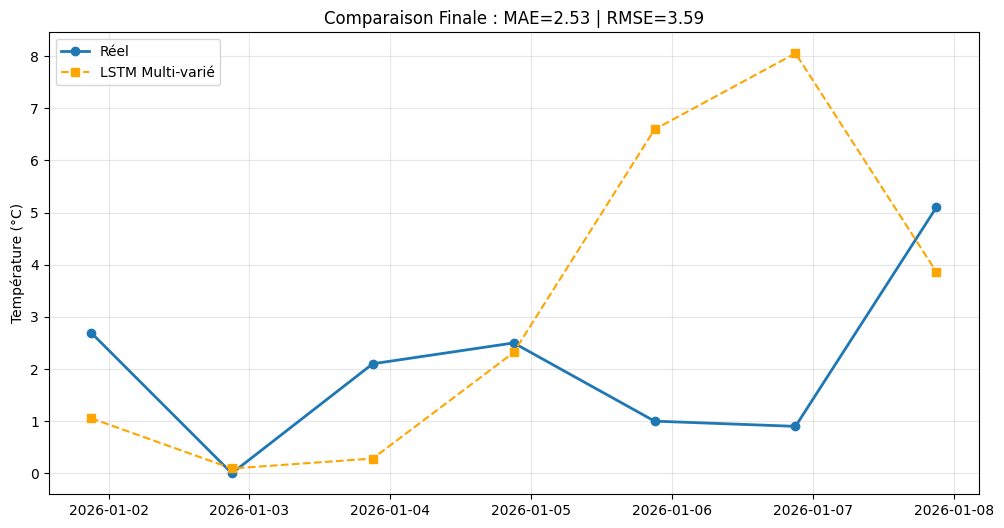

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chargement
df_pred = pd.read_csv("forecast_lstm_7days.csv")
df_real = pd.read_csv("synop_2026.csv", sep=";")

df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

# 2. Alignement
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    print(f"\n📊 RÉSULTATS DU 1er JANVIER 2026")
    print(f"MAE  : {mae:.2f} °C")
    print(f"RMSE : {rmse:.2f} °C")

    # 3. Graphique
    plt.figure(figsize=(12, 6))
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel', lw=2)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Multi-varié', color='orange')
    plt.title(f"Comparaison Finale : MAE={mae:.2f} | RMSE={rmse:.2f}")
    plt.ylabel("Température (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("❌ Erreur : Pas de données communes pour le 1er Janvier.")

Modification pour analyser les résidus (écart à la normale), on ajoute toutes les variables dont on dispose, on demande de regarder les 9 derniers jours pour affiner

In [123]:
import pandas as pd
import numpy as np
import glob
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

# ==========================================
# 1. CHARGEMENT ET NETTOYAGE MASSIF
# ==========================================
files = sorted(glob.glob("synop_*.csv"))
cols_physiques = ['validity_time', 't', 'u', 'pres', 'dd', 'ff', 'td', 'pmer', 'tend', 'tend24', 'n', 'rr1', 'name']

print("⏳ Chargement des fichiers...")
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols_physiques) for f in files])

df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

# Conversions et calculs de base
df['y'] = df['t'] - 273.15
df['dew_point'] = df['td'] - 273.15
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Nettoyage des colonnes numériques
cols_num = ['y', 'u', 'pres', 'dd', 'ff', 'dew_point', 'pmer', 'tend', 'tend24', 'n', 'rr1']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Interpolation (Correction Pandas 2.0+)
df = df.set_index('ds')[cols_num]
df['rr1'] = df['rr1'].fillna(0) # La pluie manquante = 0mm
df = df.interpolate(method='linear').bfill() 
df = df.resample('3h').interpolate(method='linear')

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
df['hour'] = df.index.hour
df['day_of_year'] = df.index.dayofyear

# Normales saisonnières (Base de 10 ans)
normales_map = df.groupby(['day_of_year', 'hour'])['y'].mean()
df['y_normal'] = [normales_map.get((d, h)) for d, h in zip(df['day_of_year'], df['hour'])]
df['residue'] = df['y'] - df['y_normal']

# Vecteurs de vent (U, V)
df['wind_u'] = df['ff'] * np.cos(np.deg2rad(df['dd']))
df['wind_v'] = df['ff'] * np.sin(np.deg2rad(df['dd']))

# Heure cyclique
df['hr_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['hr_sin', 'hr_cos', 'residue', 'u', 'pres', 'wind_u', 'wind_v', 'dew_point', 'pmer', 'tend', 'n', 'rr1']
df = df.dropna(subset=features)

# ==========================================
# 3. SCALING ET SEQUENCES
# ==========================================
scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[['residue']])

# Sauvegarde des scalers pour plus tard
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

def create_sequences(data_X, data_y, in_len=72, out_len=8):
    X, y = [], []
    for i in range(len(data_X) - in_len - out_len):
        X.append(data_X[i:i+in_len])
        y.append(data_y[i+in_len : i+in_len+out_len, 0])
    return np.array(X), np.array(y)

X_data, y_data = create_sequences(scaled_X, scaled_y)
split = int(0.85 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

# ==========================================
# 4. MODÈLE LSTM
# ==========================================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dense(32, activation='relu'),
    Dense(8)
])

model.compile(optimizer='adam', loss='mse')
print("🚀 Entraînement en cours (12 variables)...")
model.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.1)

# ==========================================
# 5. PRÉDICTION (1er JANVIER 2026)
# ==========================================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
df_past = df[df.index <= cutoff].tail(72)
last_window = scaler_X.transform(df_past[features]).reshape(1, 72, len(features))

pred_res_scaled = model.predict(last_window)
pred_residue = scaler_y.inverse_transform(pred_res_scaled).flatten()

future_dates = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=8, freq='3h')
future_normales = [normales_map.get((d.dayofyear, d.hour)) for d in future_dates]
final_forecast = pred_residue + np.array(future_normales)

# Export
df_res = pd.DataFrame({'ds': future_dates, 'y_pred': final_forecast})
df_res.to_csv("forecast_lstm_24h.csv", index=False)
model.save("modele_montpellier_final.keras")
print("\n✅ Prédictions sauvegardées dans 'forecast_lstm_24h.csv'")

⏳ Chargement des fichiers...
🚀 Entraînement en cours (12 variables)...
Epoch 1/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - loss: 0.0157 - val_loss: 0.0089
Epoch 2/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0080 - val_loss: 0.0080
Epoch 3/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0074 - val_loss: 0.0079
Epoch 4/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0072 - val_loss: 0.0075
Epoch 5/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0071 - val_loss: 0.0073
Epoch 6/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0069 - val_loss: 0.0084
Epoch 7/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.0068 - val_loss: 0.0071
Epoch 8/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 0.0065 - val_loss: 0.0072
Epoch 9/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 0.0065 - val_loss: 0.0066
Epoch 10/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0064 - val_loss: 0.0066
Epoch 11/15
384/384 ━━━━━━━━━━━━━━━━━━━━ 14s 37m


📊 RÉSULTATS DU 1er JANVIER 2026
MAE  : 1.98 °C
RMSE : 2.24 °C


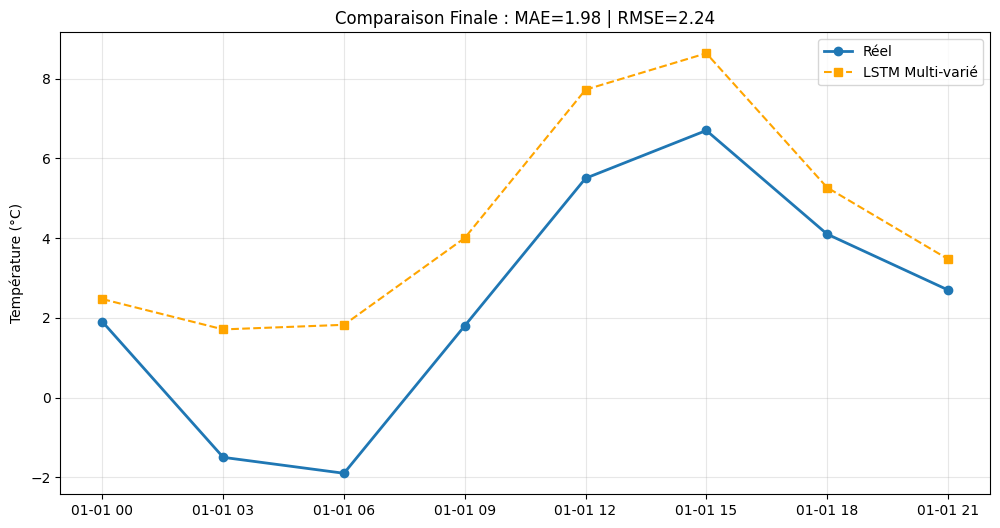

In [125]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chargement
df_pred = pd.read_csv("forecast_lstm_24h.csv")
df_real = pd.read_csv("synop_2026.csv", sep=";")

df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

# 2. Alignement
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    print(f"\n📊 RÉSULTATS DU 1er JANVIER 2026")
    print(f"MAE  : {mae:.2f} °C")
    print(f"RMSE : {rmse:.2f} °C")

    # 3. Graphique
    plt.figure(figsize=(12, 6))
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel', lw=2)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Multi-varié', color='orange')
    plt.title(f"Comparaison Finale : MAE={mae:.2f} | RMSE={rmse:.2f}")
    plt.ylabel("Température (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("❌ Erreur : Pas de données communes pour le 1er Janvier.")

Même logique mais on essaye de prédire 1 semaine d'un coup

In [ ]:
import pandas as pd
import numpy as np
import glob
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

# ==========================================
# 1. CHARGEMENT ET NETTOYAGE
# ==========================================
files = sorted(glob.glob("synop_*.csv"))
cols_physiques = ['validity_time', 't', 'u', 'pres', 'dd', 'ff', 'td', 'pmer', 'tend', 'n', 'rr1', 'name']

df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols_physiques) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

# Conversions
df['y'] = df['t'] - 273.15
df['dew_point'] = df['td'] - 273.15
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100
cols_num = ['y', 'u', 'pres', 'dd', 'ff', 'dew_point', 'pmer', 'tend', 'n', 'rr1']

for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.set_index('ds')[cols_num]
df['rr1'] = df['rr1'].fillna(0)
df = df.interpolate(method='linear').bfill() 
df = df.resample('3h').interpolate(method='linear')

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
df['hour'] = df.index.hour
df['day_of_year'] = df.index.dayofyear
normales_map = df.groupby(['day_of_year', 'hour'])['y'].mean()
df['y_normal'] = [normales_map.get((d, h)) for d, h in zip(df['day_of_year'], df['hour'])]
df['residue'] = df['y'] - df['y_normal']
df['wind_u'] = df['ff'] * np.cos(np.deg2rad(df['dd']))
df['wind_v'] = df['ff'] * np.sin(np.deg2rad(df['dd']))
df['hr_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['hr_sin', 'hr_cos', 'residue', 'u', 'pres', 'wind_u', 'wind_v', 'dew_point', 'pmer', 'tend', 'n', 'rr1']
df = df.dropna(subset=features)

# ==========================================
# 3. SCALING ET SEQUENCES (7 JOURS)
# ==========================================
scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[['residue']])

# in_len=80 (10 jours de passé) | out_len=56 (7 jours de futur)
def create_sequences(data_X, data_y, in_len=80, out_len=56):
    X, y = [], []
    for i in range(len(data_X) - in_len - out_len):
        X.append(data_X[i:i+in_len])
        y.append(data_y[i+in_len : i+in_len+out_len, 0])
    return np.array(X), np.array(y)

X_data, y_data = create_sequences(scaled_X, scaled_y)
split = int(0.85 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

# ==========================================
# 4. MODÈLE
# ==========================================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(56) # Sortie : 56 points (7 jours)
])

model.compile(optimizer='adam', loss='mse')
print("🚀 Entraînement pour 1 semaine de prédiction...")
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1)

# ==========================================
# 5. PRÉDICTION (SEMAINE DU 1er JANVIER)
# ==========================================
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
df_past = df[df.index <= cutoff].tail(80)
last_window = scaler_X.transform(df_past[features]).reshape(1, 80, len(features))

pred_res_scaled = model.predict(last_window)
pred_residue = scaler_y.inverse_transform(pred_res_scaled).flatten()

# Reconstruction sur 56 points (1 semaine)
future_dates = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=56, freq='3h')
future_normales = []
for d in future_dates:
    future_normales.append(normales_map.get((d.dayofyear, d.hour)))

final_forecast = pred_residue + np.array(future_normales)

# Export
df_res = pd.DataFrame({'ds': future_dates, 'y_pred': final_forecast})
df_res.to_csv("forecast_lstm_1week.csv", index=False)
print("✅ Prédictions 1 semaine sauvegardées.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df_pred = pd.read_csv("forecast_lstm_1week.csv")
df_real = pd.read_csv("synop_2026.csv", sep=";")

df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    plt.figure(figsize=(15, 7))
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel', color='#1f77b4')
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM (Semaine)', color='orange')
    
    plt.title(f"Validation sur 1 semaine : MAE {mae:.2f}°C | RMSE {rmse:.2f}°C")
    plt.ylabel("Température (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("❌ Aucune donnée de comparaison trouvée pour cette semaine.")

lstm récursif en prédisant point par point pour toute une semaine, on utilise uniquement les variables temperature humidite et pression

In [ ]:
import pandas as pd
import numpy as np
import glob
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

# 1. CHARGEMENT & NETTOYAGE (Identique au précédent)
files = sorted(glob.glob("synop_*.csv"))
cols_physiques = ['validity_time', 't', 'u', 'pres', 'dd', 'ff', 'td', 'name']
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=cols_physiques) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce')
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100
df = df.set_index('ds')[['y', 'u', 'pres']]
df = df.interpolate(method='linear').bfill()
df = df.resample('3h').interpolate(method='linear')

# 2. SEQUENCES POUR PRÉDIRE 1 SEUL POINT (T+1)
features = ['y', 'u', 'pres'] # On simplifie pour stabiliser la récursion
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

def create_single_step_sequences(data, in_len=48): # Regarde 6 jours (48 points)
    X, y = [], []
    for i in range(len(data) - in_len):
        X.append(data[i:i+in_len])
        y.append(data[i+in_len, 0]) # On prédit uniquement 'y' (température)
    return np.array(X), np.array(y)

X_data, y_data = create_single_step_sequences(scaled_data)
model = Sequential([
    Input(shape=(X_data.shape[1], X_data.shape[2])),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1) # SORTIE UNIQUE
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_data, y_data, epochs=10, batch_size=64, verbose=1)

# 3. BOUCLE DE PRÉDICTION RÉCURSIVE (LE CŒUR DU SYSTÈME)
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
current_window = scaled_data[df.index <= cutoff][-48:] # Les 48 derniers points réels
predictions_scaled = []

print("🔄 Génération de la semaine point par point...")
for i in range(56): # 7 jours = 56 points de 3h
    # Predire le point suivant
    input_seq = current_window.reshape(1, 48, len(features))
    pred_y_scaled = model.predict(input_seq, verbose=0)[0, 0]
    
    # Stocker la prédiction
    predictions_scaled.append(pred_y_scaled)
    
    # Construire le nouveau vecteur pour l'étape suivante
    # Note : On réutilise les dernières valeurs de 'u' et 'pres' réelles ou moyennes 
    # pour simplifier, ou on pourrait aussi les prédire. Ici on garde les dernières connues.
    last_u_pres = current_window[-1, 1:] 
    new_entry = np.array([pred_y_scaled, *last_u_pres])
    
    # Faire glisser la fenêtre : on enlève le premier, on ajoute le nouveau
    current_window = np.vstack([current_window[1:], new_entry])

# 4. DE-SCALING ET EXPORT
# Pour dé-scaler une seule colonne, on ruse en créant un vecteur factice
dummy = np.zeros((len(predictions_scaled), len(features)))
dummy[:, 0] = predictions_scaled
final_temp = scaler.inverse_transform(dummy)[:, 0]

future_dates = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=56, freq='3h')
df_res = pd.DataFrame({'ds': future_dates, 'y_pred': final_temp})
df_res.to_csv("forecast_lstm_recursive.csv", index=False)
print("✅ Terminé. Utilise ton script de comparaison habituel sur 'forecast_lstm_recursive.csv'.")

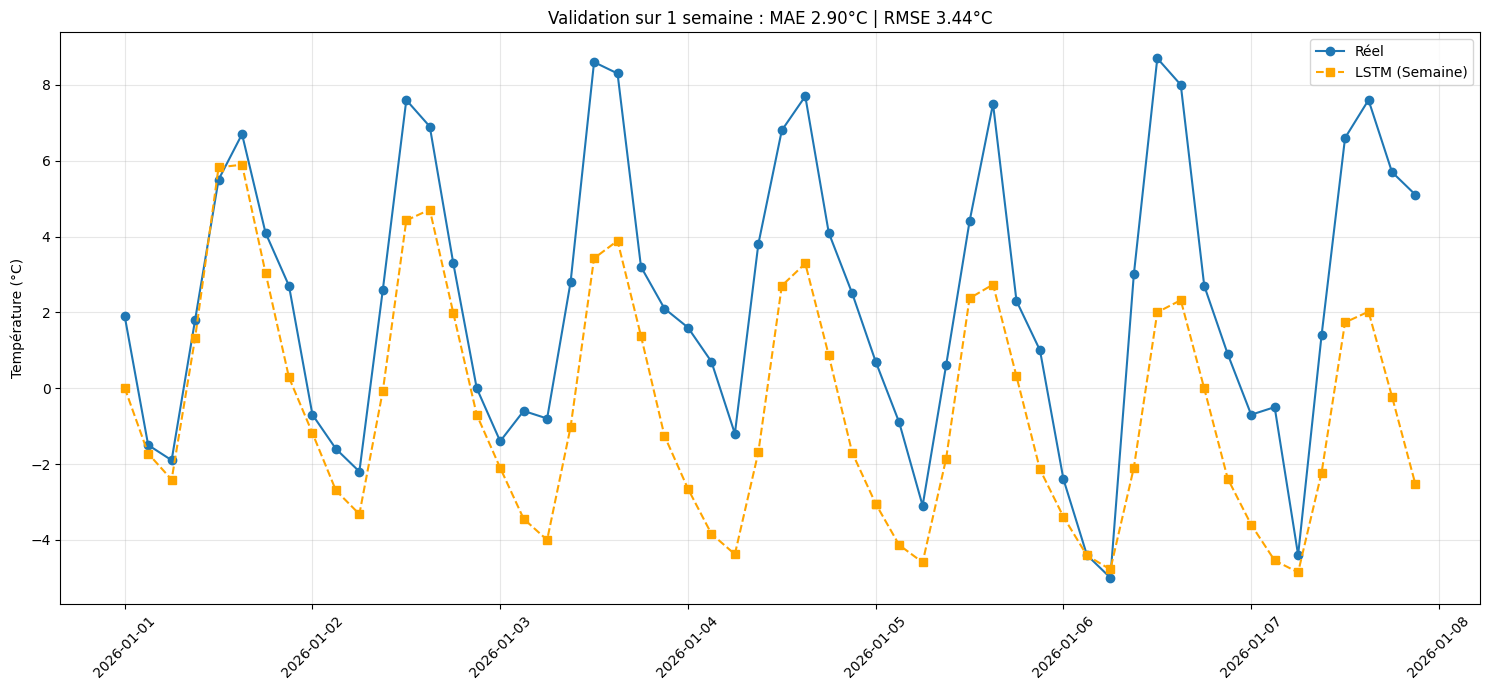

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df_pred = pd.read_csv("forecast_lstm_recursive.csv")
df_real = pd.read_csv("synop_2026.csv", sep=";")

df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    plt.figure(figsize=(15, 7))
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel', color='#1f77b4')
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM (Semaine)', color='orange')
    
    plt.title(f"Validation sur 1 semaine : MAE {mae:.2f}°C | RMSE {rmse:.2f}°C")
    plt.ylabel("Température (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("❌ Aucune donnée de comparaison trouvée pour cette semaine.")

In [ ]:
lstm recursif en ayant transformé l'heure et le jour de l'année en fonctions sinus et cosinus

In [ ]:
import pandas as pd
import numpy as np
import glob
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# 1. PRÉPARATION PRO (On utilise StandardScaler pour mieux gérer les extrêmes)
files = sorted(glob.glob("synop_*.csv"))
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce')
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Features Circulaires (Heure et Saison)
df['hour_sin'] = np.sin(2 * np.pi * df.ds.dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.ds.dt.hour / 24)
df['day_sin'] = np.sin(2 * np.pi * df.ds.dt.dayofyear / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df.ds.dt.dayofyear / 365.25)

df = df.set_index('ds')[['y', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']].interpolate().bfill()
df = df.resample('3h').interpolate()

# 2. ENTRAÎNEMENT
features = ['y', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

X, y = [], []
in_len = 56 # On regarde 1 semaine en arrière
for i in range(len(scaled_data) - in_len):
    X.append(scaled_data[i:i+in_len])
    y.append(scaled_data[i+in_len, 0])

X, y = np.array(X), np.array(y)

model = Sequential([
    Input(shape=(in_len, len(features))),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae') # MAE est plus robuste aux outliers que MSE
model.fit(X, y, epochs=15, batch_size=32, validation_split=0.1, 
          callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])

# 3. PRÉDICTION RÉCURSIVE
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
current_window = scaled_data[df.index <= cutoff][-in_len:]
final_forecast = []

print("🔄 Calcul de la trajectoire thermique...")
for i in range(56):
    pred_scaled = model.predict(current_window.reshape(1, in_len, len(features)), verbose=0)[0, 0]
    
    # On dé-scale pour obtenir la température en °C
    temp_c = (pred_scaled * scaler.scale_[0]) + scaler.mean_[0]
    final_forecast.append(temp_c)
    
    # On prépare le point suivant (on simule l'heure et le jour pour les features circ)
    future_date = cutoff + pd.Timedelta(hours=3*(i+1))
    new_features = [
        pred_scaled, # La température prédite
        current_window[-1, 1], # On garde l'humidité
        current_window[-1, 2], # On garde la pression
        np.sin(2 * np.pi * future_date.hour / 24),
        np.cos(2 * np.pi * future_date.hour / 24),
        np.sin(2 * np.pi * future_date.dayofyear / 365.25),
        np.cos(2 * np.pi * future_date.dayofyear / 365.25)
    ]
    current_window = np.vstack([current_window[1:], new_features])

# Export
pd.DataFrame({'ds': pd.date_range(cutoff + pd.Timedelta(hours=3), periods=56, freq='3h'), 
              'y_pred': final_forecast}).to_csv("forecast_final.csv", index=False)

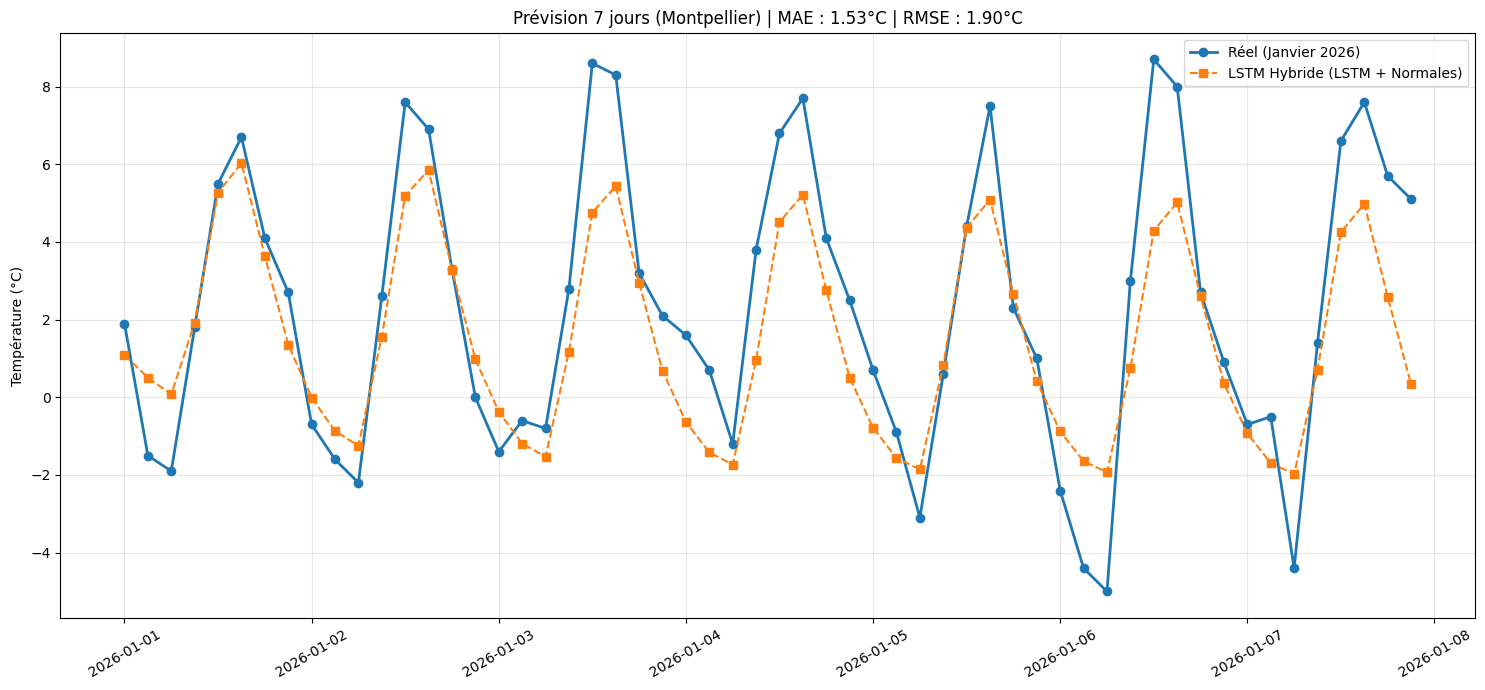

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Chargement
df_pred = pd.read_csv("forecast_final.csv")
df_real = pd.read_csv("synop_2026.csv", sep=";")

df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    plt.figure(figsize=(15, 7))
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel (Janvier 2026)', color='#1f77b4', lw=2)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Hybride (LSTM + Normales)', color='#ff7f0e')
    
    plt.title(f"Prévision 7 jours (Montpellier) | MAE : {mae:.2f}°C | RMSE : {rmse:.2f}°C")
    plt.ylabel("Température (°C)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

même modèle mais pour prédire 2 semaines:

In [ ]:
import pandas as pd
import numpy as np
import glob
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# 1. CHARGEMENT ET PRÉPARATION
files = sorted(glob.glob("synop_*.csv"))
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce')
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Features Circulaires
df['hour_sin'] = np.sin(2 * np.pi * df.ds.dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.ds.dt.hour / 24)
df['day_sin'] = np.sin(2 * np.pi * df.ds.dt.dayofyear / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df.ds.dt.dayofyear / 365.25)

df = df.set_index('ds')[['y', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']].interpolate().bfill()
df = df.resample('3h').interpolate()

# 2. ENTRAÎNEMENT
features = ['y', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

X, y = [], []
in_len = 80 # On augmente un peu le regard en arrière (10 jours) pour stabiliser les 14 jours futurs
for i in range(len(scaled_data) - in_len):
    X.append(scaled_data[i:i+in_len])
    y.append(scaled_data[i+in_len, 0])

X, y = np.array(X), np.array(y)

model = Sequential([
    Input(shape=(in_len, len(features))),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae')
print("🚀 Entraînement pour l'horizon 14 jours...")
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.1, 
          callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])

# 3. PRÉDICTION RÉCURSIVE (112 POINTS / 2 SEMAINES)
cutoff = pd.Timestamp("2025-12-31 21:00:00", tz='UTC')
current_window = scaled_data[df.index <= cutoff][-in_len:]
final_forecast = []

# Paramètres de dé-scaling rapides
mean_y = scaler.mean_[0]
scale_y = scaler.scale_[0]

print("🔄 Calcul de la trajectoire sur 2 semaines...")
for i in range(112): # 14 jours * 8 points/jour
    pred_scaled = model.predict(current_window.reshape(1, in_len, len(features)), verbose=0)[0, 0]
    
    # Stockage de la température réelle
    temp_c = (pred_scaled * scale_y) + mean_y
    final_forecast.append(temp_c)
    
    # Calcul des features temporelles pour le point futur
    future_date = cutoff + pd.Timedelta(hours=3*(i+1))
    
    # On assemble le vecteur d'entrée pour l'étape suivante
    new_features = [
        pred_scaled,
        current_window[-1, 1], # Humidité (stagnante ou pourrait être une moyenne)
        current_window[-1, 2], # Pression
        np.sin(2 * np.pi * future_date.hour / 24),
        np.cos(2 * np.pi * future_date.hour / 24),
        np.sin(2 * np.pi * future_date.dayofyear / 365.25),
        np.cos(2 * np.pi * future_date.dayofyear / 365.25)
    ]
    current_window = np.vstack([current_window[1:], new_features])

# 4. EXPORT
dates_2w = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=112, freq='3h')
pd.DataFrame({'ds': dates_2w, 'y_pred': final_forecast}).to_csv("forecast_2_weeks.csv", index=False)
print("✅ Prédiction 14 jours exportée dans 'forecast_2_weeks.csv'")

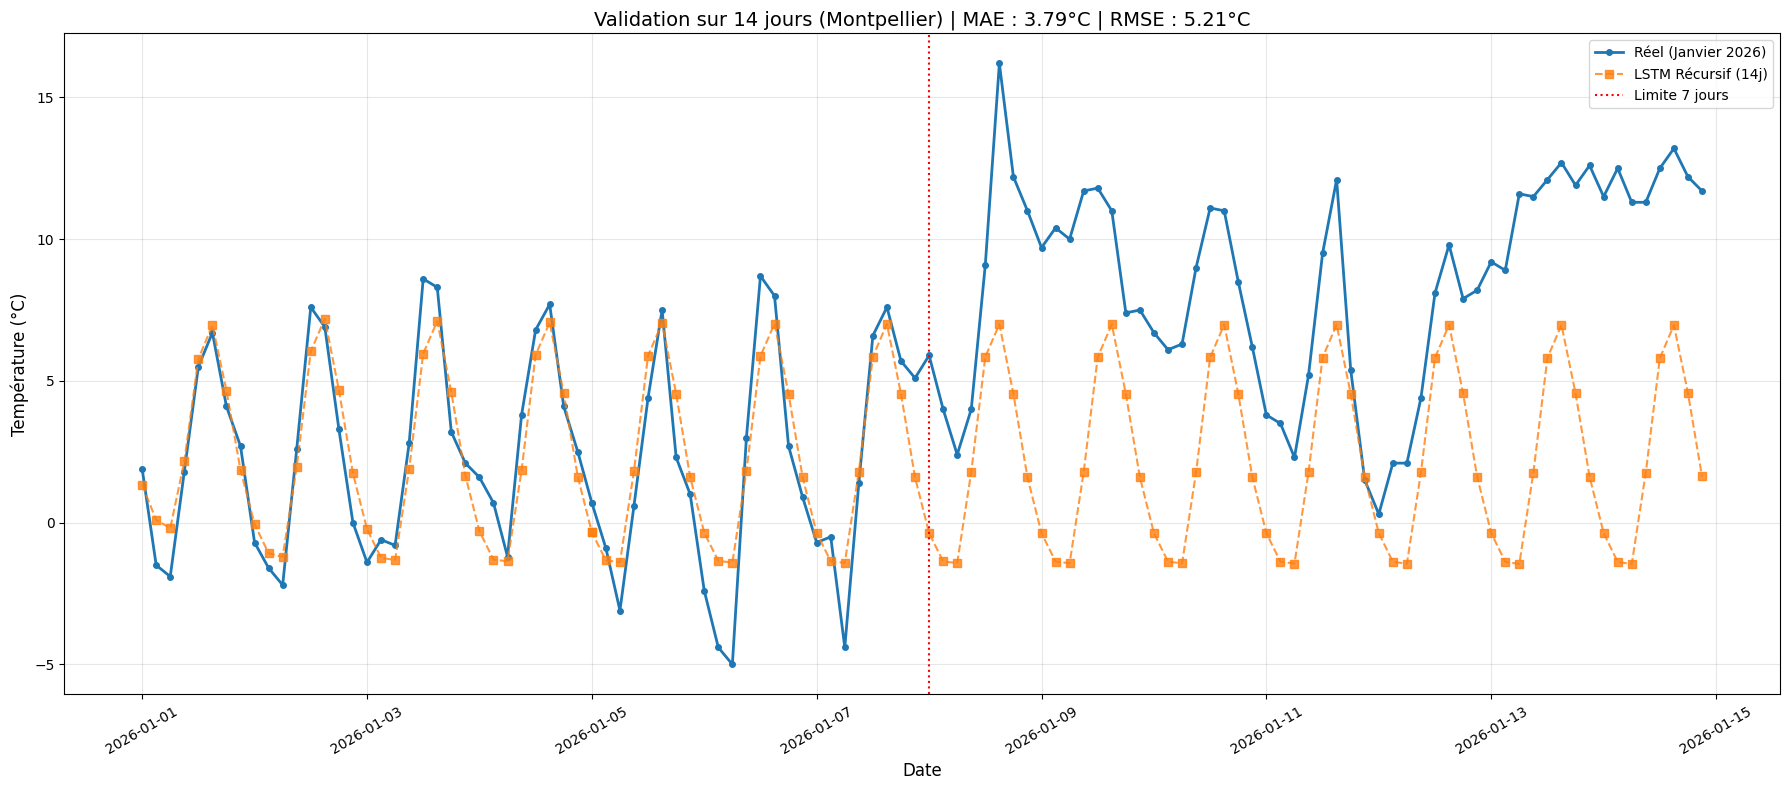

📊 RÉSULTATS 2 SEMAINES
MAE  : 3.79 °C
RMSE : 5.21 °C


In [128]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chargement des données (Prévues vs Réelles)
try:
    df_pred = pd.read_csv("forecast_2_weeks.csv")
    df_real = pd.read_csv("synop_2026.csv", sep=";") # Assure-toi que ce fichier contient bien les 15 premiers jours de janv
except FileNotFoundError:
    print("Erreur : Assure-toi que 'forecast_2_weeks.csv' et 'synop_2026.csv' sont dans le dossier.")

# 2. Nettoyage et conversion
df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)

# Conversion Kelvin vers Celsius
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

# 3. Fusion pour aligner les dates
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    # Calcul des métriques sur les 14 jours
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    # 4. Visualisation
    plt.figure(figsize=(18, 8))
    
    # Courbes
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel (Janvier 2026)', color='#1f77b4', lw=2, markersize=4)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Récursif (14j)', color='#ff7f0e', alpha=0.8)
    
    # Ligne de séparation 1ère / 2ème semaine
    sep_date = df_compare['ds'].iloc[0] + pd.Timedelta(days=7)
    plt.axvline(x=sep_date, color='red', linestyle=':', label='Limite 7 jours')
    
    # Style
    plt.title(f"Validation sur 14 jours (Montpellier) | MAE : {mae:.2f}°C | RMSE : {rmse:.2f}°C", fontsize=14)
    plt.ylabel("Température (°C)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 RÉSULTATS 2 SEMAINES")
    print(f"MAE  : {mae:.2f} °C")
    print(f"RMSE : {rmse:.2f} °C")
else:
    print("❌ Aucune donnée commune trouvée. Vérifie que 'synop_2026.csv' couvre bien jusqu'au 14 Janvier.")

Modification du modèle précedent en predisant le résidu, ajout d'un coef de rappel mathématique, on intégre la tendance de la temperature

In [ ]:
import pandas as pd
import numpy as np
import glob
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# 1. CHARGEMENT ET PRÉPARATION (Incluant début Janvier 2026)
files = sorted(glob.glob("synop_*.csv"))
df_raw = pd.concat([pd.read_csv(f, sep=None, engine='python', usecols=['validity_time', 't', 'u', 'pres', 'name']) for f in files])
df_raw['ds'] = pd.to_datetime(df_raw['validity_time'], utc=True)
df = df_raw[df_raw['name'] == "MONTPELLIER-AEROPORT"].drop_duplicates('ds').sort_values('ds').copy()

df['y'] = df['t'] - 273.15
df['u'] = pd.to_numeric(df['u'], errors='coerce')
df['pres'] = pd.to_numeric(df['pres'], errors='coerce') / 100

# Features temporelles
df['hour_sin'] = np.sin(2 * np.pi * df.ds.dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.ds.dt.hour / 24)
df['day_sin'] = np.sin(2 * np.pi * df.ds.dt.dayofyear / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df.ds.dt.dayofyear / 365.25)

# Tendance et Résidu pour la stabilité à long terme
df['trend'] = df['y'].rolling(window=8, min_periods=1, center=True).mean()
df['residue'] = df['y'] - df['trend']

df = df.set_index('ds')[['residue', 'trend', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']].interpolate().bfill()
df = df.resample('3h').interpolate()

# 2. ENTRAÎNEMENT
features = ['residue', 'trend', 'u', 'pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

X, y = [], []
in_len = 80 
for i in range(len(scaled_data) - in_len):
    X.append(scaled_data[i:i+in_len])
    y.append(scaled_data[i+in_len, 0]) # On prédit le résidu (la vibration)

X, y = np.array(X), np.array(y)

model = Sequential([
    Input(shape=(in_len, len(features))),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mae')
print("🚀 Entraînement sur les cycles thermiques...")
model.fit(X, y, epochs=15, batch_size=32, verbose=1, callbacks=[EarlyStopping(patience=3)])

# 3. PRÉDICTION RÉCURSIVE : SEMAINES 2 & 3
# On déplace le cutoff au 7 Janvier 2026 à 21h pour prédire la suite
cutoff = pd.Timestamp("2026-01-07 21:00:00", tz='UTC')

# Trouver l'indice de départ dans les données scalées
idx_cutoff = df.index.get_indexer([cutoff], method='pad')[0]
current_window = scaled_data[idx_cutoff - in_len + 1 : idx_cutoff + 1]
last_trend = df.iloc[idx_cutoff]['trend']

final_forecast = []
res_mean, res_scale = scaler.mean_[0], scaler.scale_[0]
trend_mean, trend_scale = scaler.mean_[1], scaler.scale_[1]

print(f"🔄 Prédiction du 08/01 au 21/01 à partir du point : {df.index[idx_cutoff]}")

for i in range(112): # 14 jours
    pred_res_scaled = model.predict(current_window.reshape(1, in_len, len(features)), verbose=0)[0, 0]
    pred_res = (pred_res_scaled * res_scale) + res_mean
    
    # Évolution de la tendance : retour très lent vers 8°C (normale Montpellier)
    last_trend = last_trend * 0.99 + 8.0 * 0.01 
    
    temp_final = last_trend + pred_res
    final_forecast.append(temp_final)
    
    # Date future pour les features temporelles
    f_date = cutoff + pd.Timedelta(hours=3*(i+1))
    
    # Mise à jour de la fenêtre
    new_entry = [
        pred_res_scaled,
        (last_trend - trend_mean) / trend_scale,
        current_window[-1, 2], # Humidité
        current_window[-1, 3], # Pression
        np.sin(2 * np.pi * f_date.hour / 24),
        np.cos(2 * np.pi * f_date.hour / 24),
        np.sin(2 * np.pi * f_date.dayofyear / 365.25),
        np.cos(2 * np.pi * f_date.dayofyear / 365.25)
    ]
    current_window = np.vstack([current_window[1:], new_entry])

# 4. EXPORT
dates_future = pd.date_range(cutoff + pd.Timedelta(hours=3), periods=112, freq='3h')
pd.DataFrame({'ds': dates_future, 'y_pred': final_forecast}).to_csv("forecast_janvier_sem2_3.csv", index=False)
print("✅ Fichier 'forecast_janvier_sem2_3.csv' généré.")

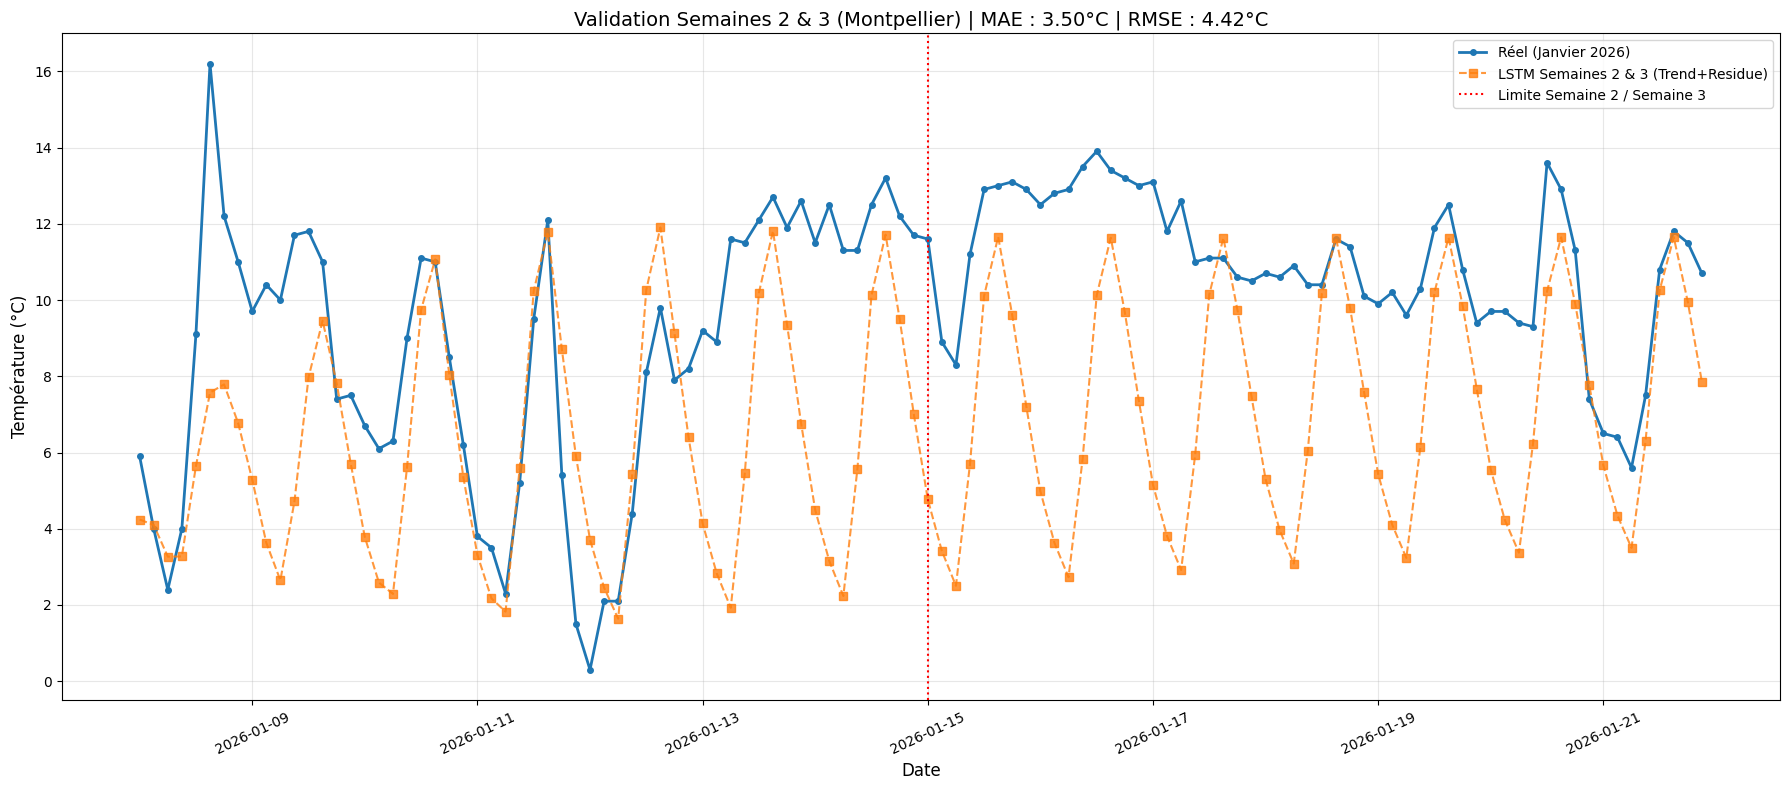

📊 RÉSULTATS SEMAINES 2 & 3
Période : du 2026-01-08 00:00:00+00:00 au 2026-01-21 21:00:00+00:00
MAE  : 3.50 °C
RMSE : 4.42 °C


In [129]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Chargement des données
try:
    # Le fichier généré par le script précédent
    df_pred = pd.read_csv("forecast_janvier_sem2_3.csv")
    # Tes données réelles (assure-toi qu'elles vont jusqu'au 21 janvier)
    df_real = pd.read_csv("synop_2026.csv", sep=";") 
except FileNotFoundError:
    print("❌ Erreur : Fichiers manquants. Vérifie 'forecast_janvier_sem2_3.csv' et 'synop_2026.csv'.")

# 2. Nettoyage et Alignement
df_pred['ds'] = pd.to_datetime(df_pred['ds'], utc=True)
df_real['ds'] = pd.to_datetime(df_real['validity_time'], utc=True)

# Conversion Kelvin -> Celsius et filtrage Montpellier
df_real['y_real'] = df_real['t'] - 273.15
df_real = df_real[df_real['name'] == "MONTPELLIER-AEROPORT"].copy()

# Fusion des données sur les dates communes
df_compare = pd.merge(df_pred, df_real[['ds', 'y_real']], on='ds', how='inner').sort_values('ds')

if not df_compare.empty:
    # 3. Calcul des métriques
    mae = mean_absolute_error(df_compare['y_real'], df_compare['y_pred'])
    rmse = np.sqrt(mean_squared_error(df_compare['y_real'], df_compare['y_pred']))

    # 4. Visualisation
    plt.figure(figsize=(18, 8))
    
    # Tracé des courbes
    plt.plot(df_compare['ds'], df_compare['y_real'], 'o-', label='Réel (Janvier 2026)', color='#1f77b4', lw=2, markersize=4)
    plt.plot(df_compare['ds'], df_compare['y_pred'], 's--', label='LSTM Semaines 2 & 3 (Trend+Residue)', color='#ff7f0e', alpha=0.8)
    
    # Ligne de séparation entre Semaine 2 et Semaine 3
    sep_date = df_compare['ds'].iloc[0] + pd.Timedelta(days=7)
    plt.axvline(x=sep_date, color='red', linestyle=':', label='Limite Semaine 2 / Semaine 3')
    
    # Mise en forme
    plt.title(f"Validation Semaines 2 & 3 (Montpellier) | MAE : {mae:.2f}°C | RMSE : {rmse:.2f}°C", fontsize=14)
    plt.ylabel("Température (°C)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.xticks(rotation=25)
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 RÉSULTATS SEMAINES 2 & 3")
    print(f"Période : du {df_compare['ds'].min()} au {df_compare['ds'].max()}")
    print(f"MAE  : {mae:.2f} °C")
    print(f"RMSE : {rmse:.2f} °C")
else:
    print("❌ Aucune donnée commune. Vérifie que 'synop_2026.csv' contient bien les données après le 08/01/2026.")